In [2]:
from pathlib import Path
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [3]:
def read_series(path, date_col=0, usecols=None, drop_first_col=False, sort=False):
    df = pd.read_csv(path, parse_dates=[date_col], index_col=date_col, usecols=usecols)
    if drop_first_col:
        df = df.drop(columns=df.columns[0])
    s = df.squeeze()
    return s.sort_index() if sort else s


DATA = Path("/home/py/groundwater/data")
BOW_VALLEY = DATA / "bow_valley"
STREAM = BOW_VALLEY / "stream"

GOWN = pd.read_csv(DATA / "gown" / "combined_absval_20052024_filled.csv", parse_dates=[0], index_col=0)

marmot_creek_wells = ['0931', '0301', '0303', '0386', '0305']
canmore_wells = ['0764', '0760', '0759', '0364']

krns = read_series(STREAM / "krns_daily.csv")
bl   = read_series(STREAM / "05BF025_BarrierLk_TAU_Day_Mean.csv")
lkl  = read_series(STREAM / "05BF009.csv")
jcnc = read_series(STREAM / "05BH013.csv", sort=True)
brac_e = read_series(STREAM / "cr.csv", usecols=[0, 2])
brab   = read_series(STREAM / "brab_elevation.csv", usecols=[0, 2])
brac = read_series(STREAM / "cr_flow.csv", date_col=1, drop_first_col=True)

In [ ]:
# def xcorr_daily(x, y, max_lag=30):
#     """Pearson r at daily lags. Positive lag = x leads y."""
#     x = x.resample('D').mean()
#     y = y.resample('D').mean()
#     x, y = x.align(y, join='inner')       # keeps only overlapping dates

#     lags = np.arange(-max_lag, max_lag + 1)
#     r = [x.corr(y.shift(-lag)) for lag in lags]
#     return pd.Series(r, index=lags, name='r')

In [26]:
def xcorr_daily(x, y, max_lag=30):
    """Pearson r at daily lags. Positive lag = x leads y.
    Lags with fewer than min_periods overlapping valid days return NaN."""
    x = x.resample('D').mean()
    y = y.resample('D').mean()
    x, y = x.align(y, join='inner')       # keeps only overlapping dates

    lags = np.arange(-max_lag, max_lag + 1)
    r = [x.corr(y.shift(-lag), min_periods=365) for lag in lags]
    return pd.Series(r, index=lags, name='r')

In [16]:
def plot_xcorr(r, label=''):
    valid = r.dropna()

    if valid.empty:
        raise ValueError("No lag has enough overlapping data, lower min_periods or check input series")

    peak_lag = valid.idxmax()
    peak_val = valid.max()

    fig, ax = plt.subplots(figsize=(9, 4), dpi=200)

    ax.fill_between(r.index, 0, r.values, alpha=0.15, color="#28549a", lw=0)
    ax.plot(r.index, r.values, color="#05131B", lw=1)

    ax.axhline(0, color='0.4', lw=0.8)
    ax.axvline(0, color='0.4', lw=0.8, ls=':')

    ax.plot(peak_lag, peak_val, 'o', color='#ffbe0b', ms=7, zorder=5)
    ax.annotate(f'{peak_lag:+d} d, r = {peak_val:.3f}',
                    xy=(peak_lag, peak_val),
                    xytext=(0, 12 if peak_val > 0 else -20),
                    textcoords='offset points',
                    ha='center', color='crimson', fontsize=10)

    ax.set_xlabel('lag (days)')
    ax.set_ylabel('Pearson r')
    ax.set_title(label, fontweight='bold')
    ax.set_xlim(r.index.min(), r.index.max())
    ax.margins(y=0.15)
    ax.grid(alpha=0.35, lw=0.5)

    return peak_lag, peak_val

# BR at Canmore Elevation vs Canmore Wells

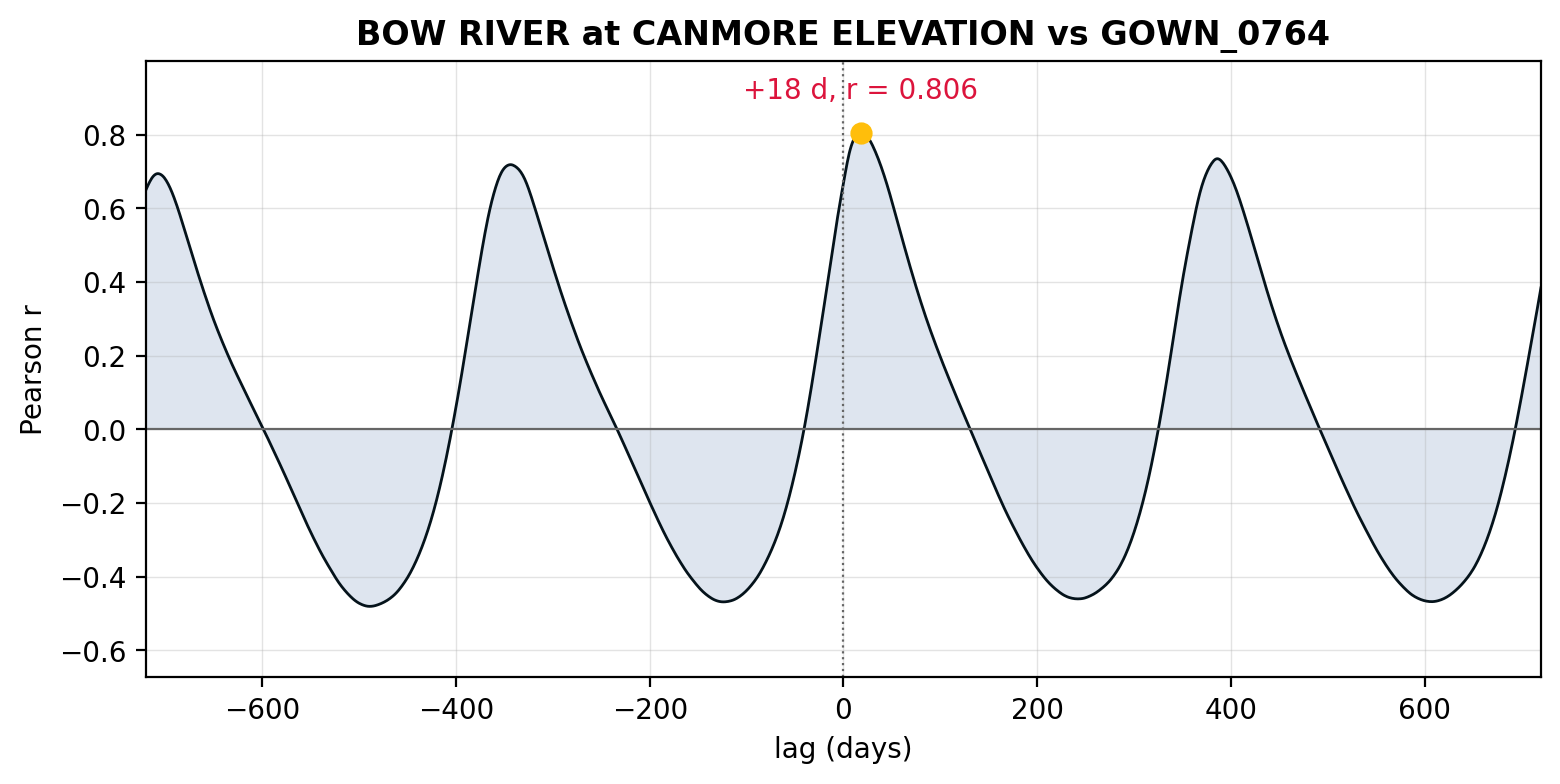

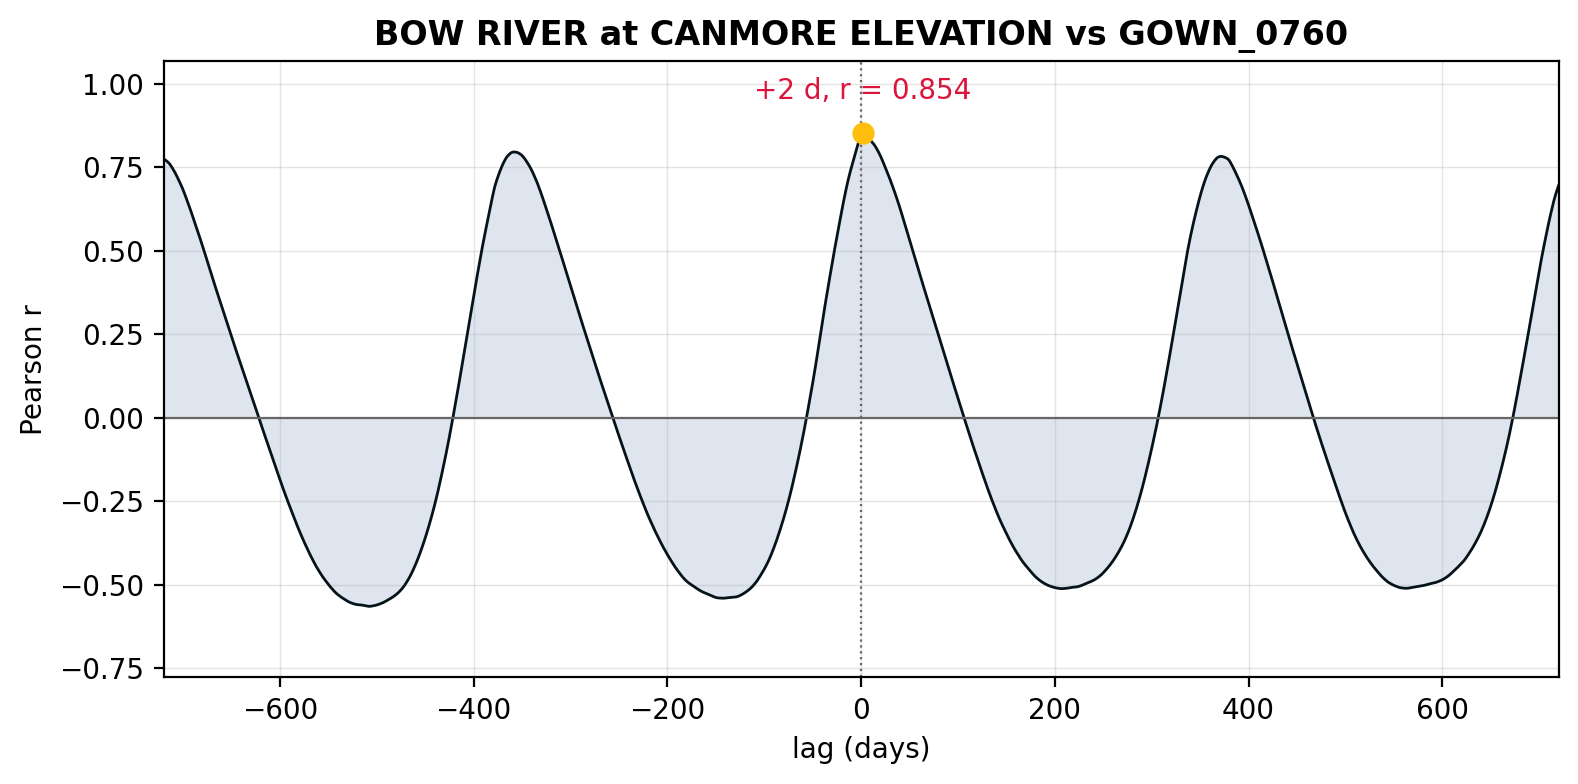

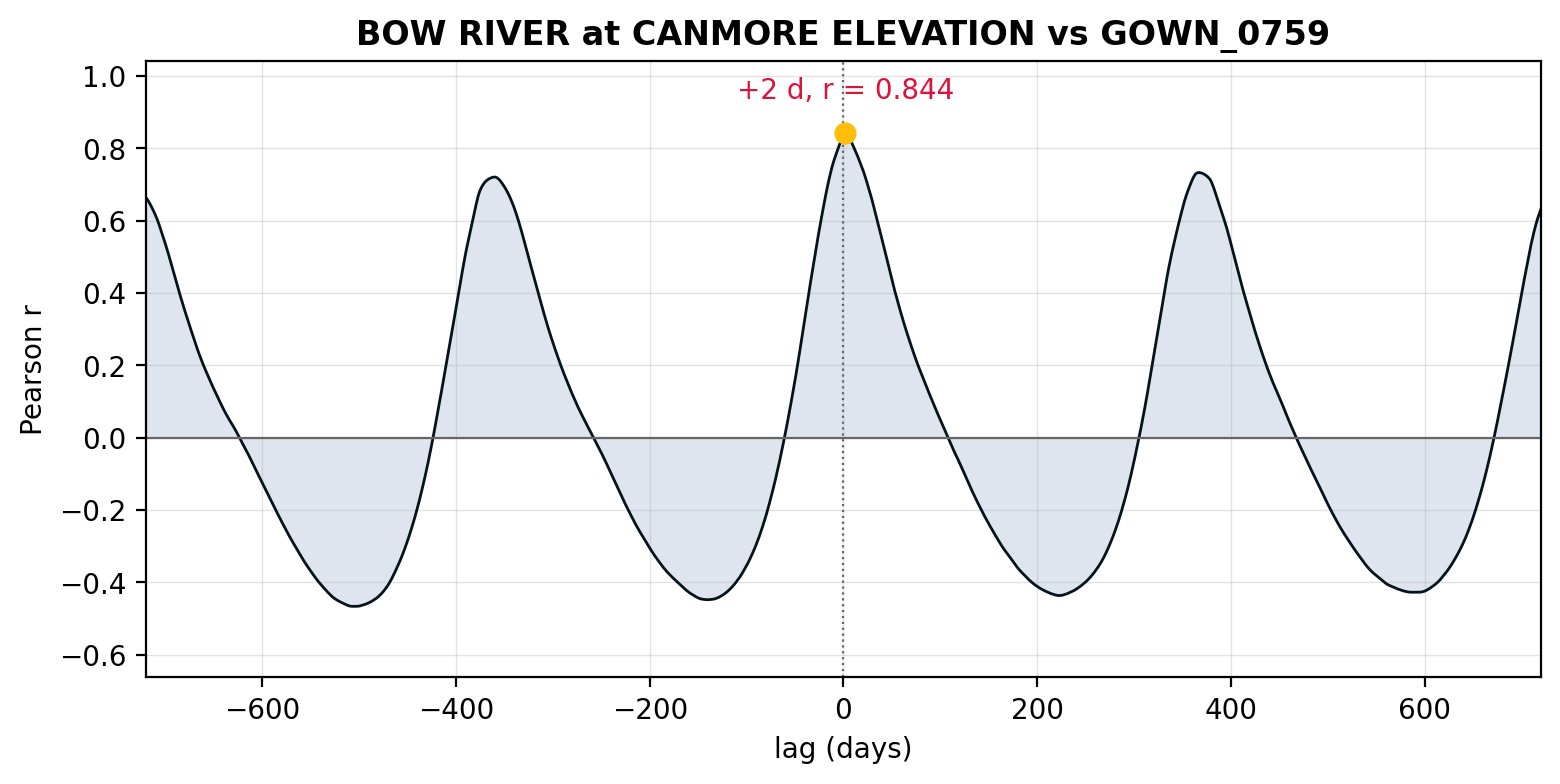

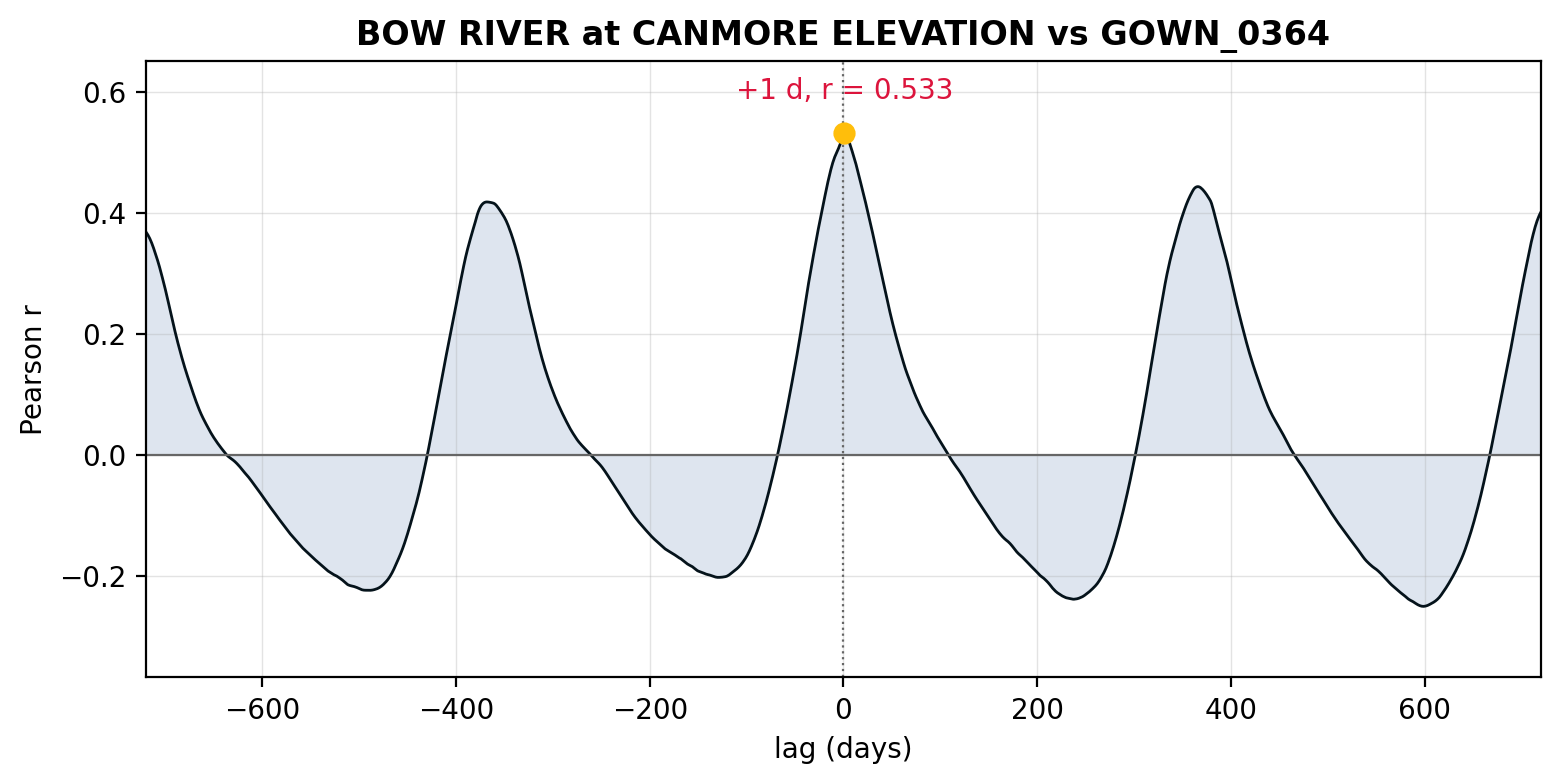

In [27]:
for well in canmore_wells:
    r = xcorr_daily(brac_e, GOWN[well], max_lag=720)
    plot_xcorr(r, f"BOW RIVER at CANMORE ELEVATION vs GOWN_{well}")

# Bow River at Canmore Flow vs Canmore Wells

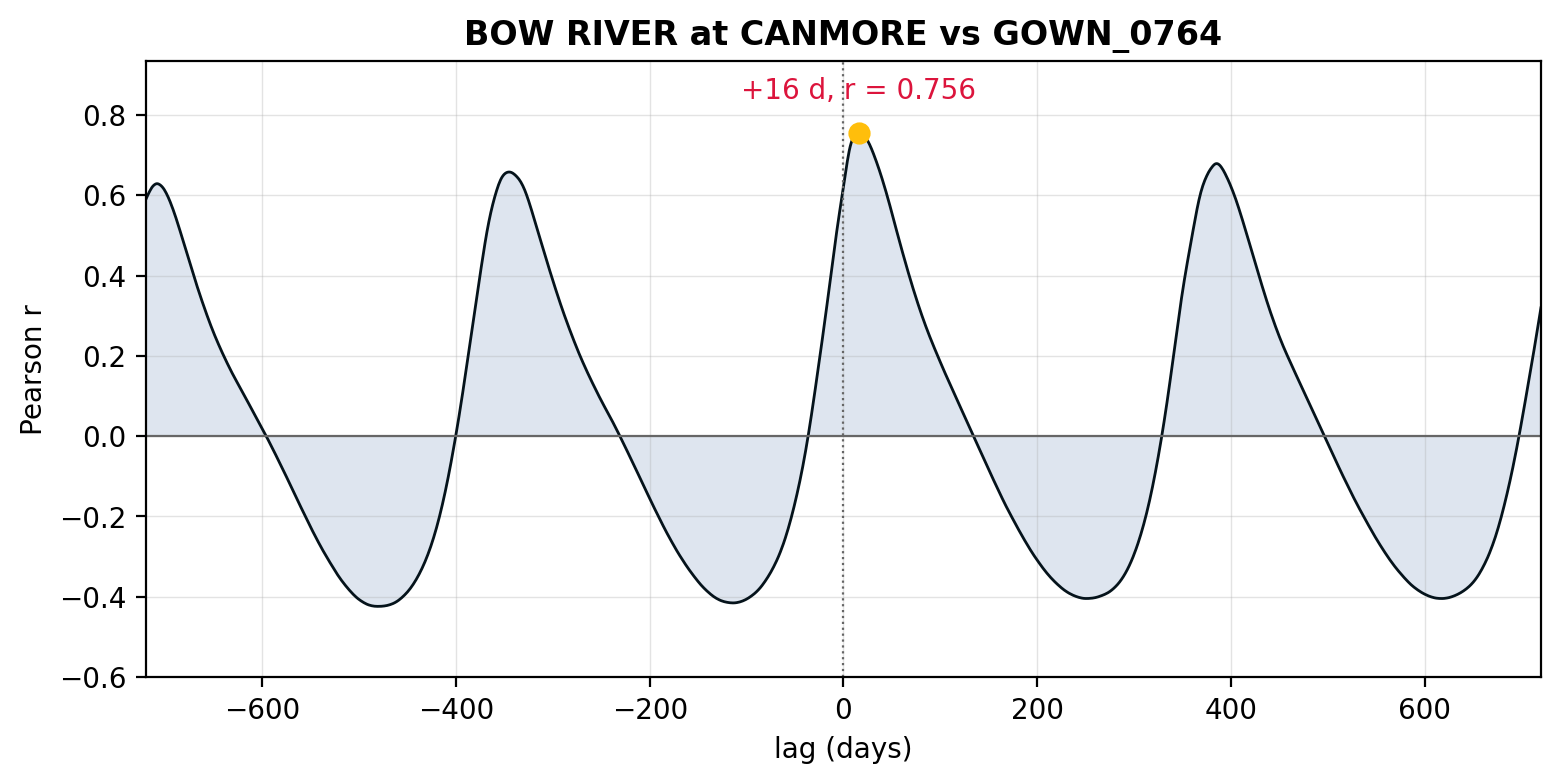

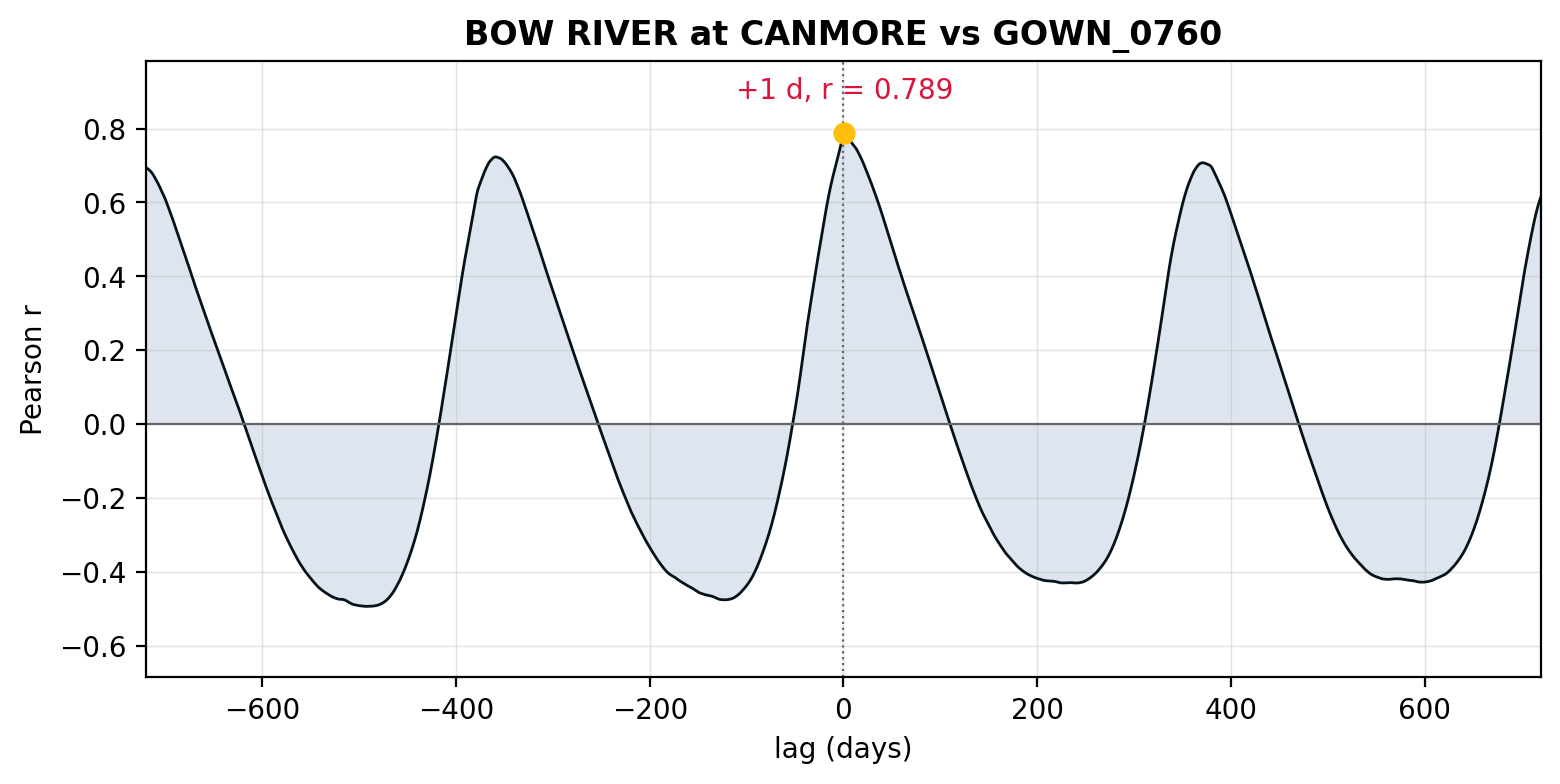

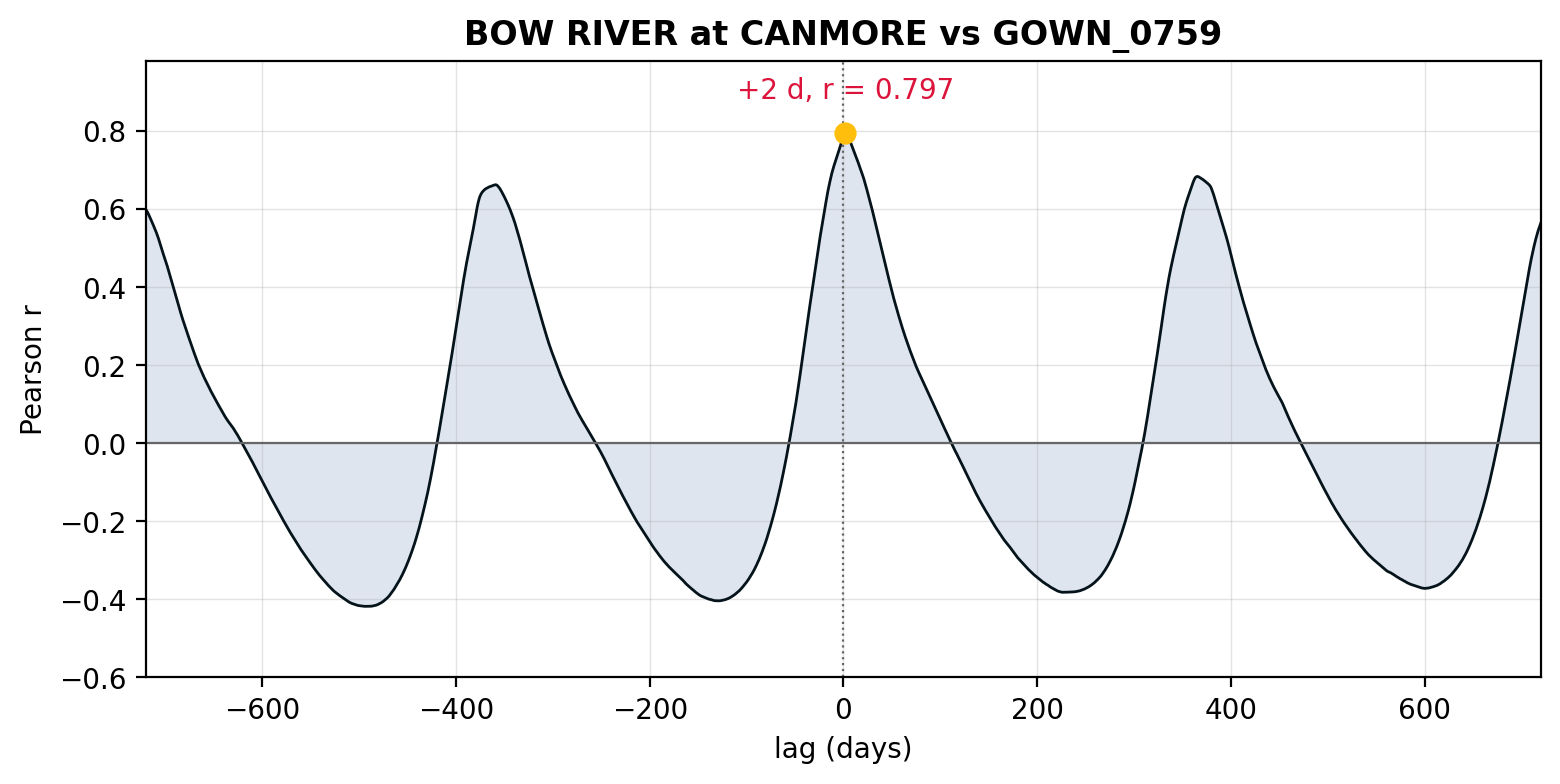

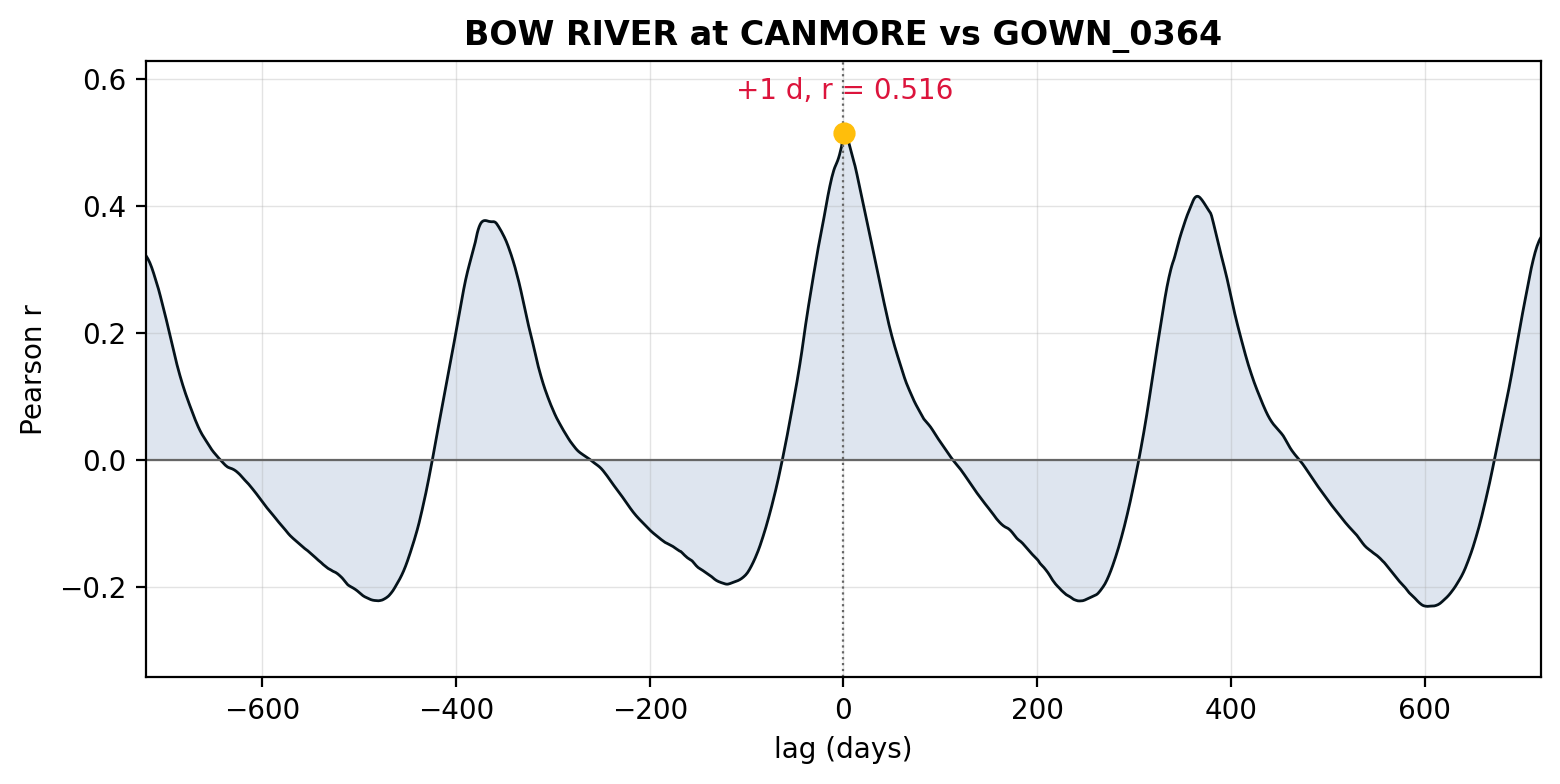

In [18]:
for well in canmore_wells:
    r = xcorr_daily(brac, GOWN[well], max_lag=720)
    plot_xcorr(r, f"BOW RIVER at CANMORE vs GOWN_{well}")

# Bow River at Banff vs Canmore Wells

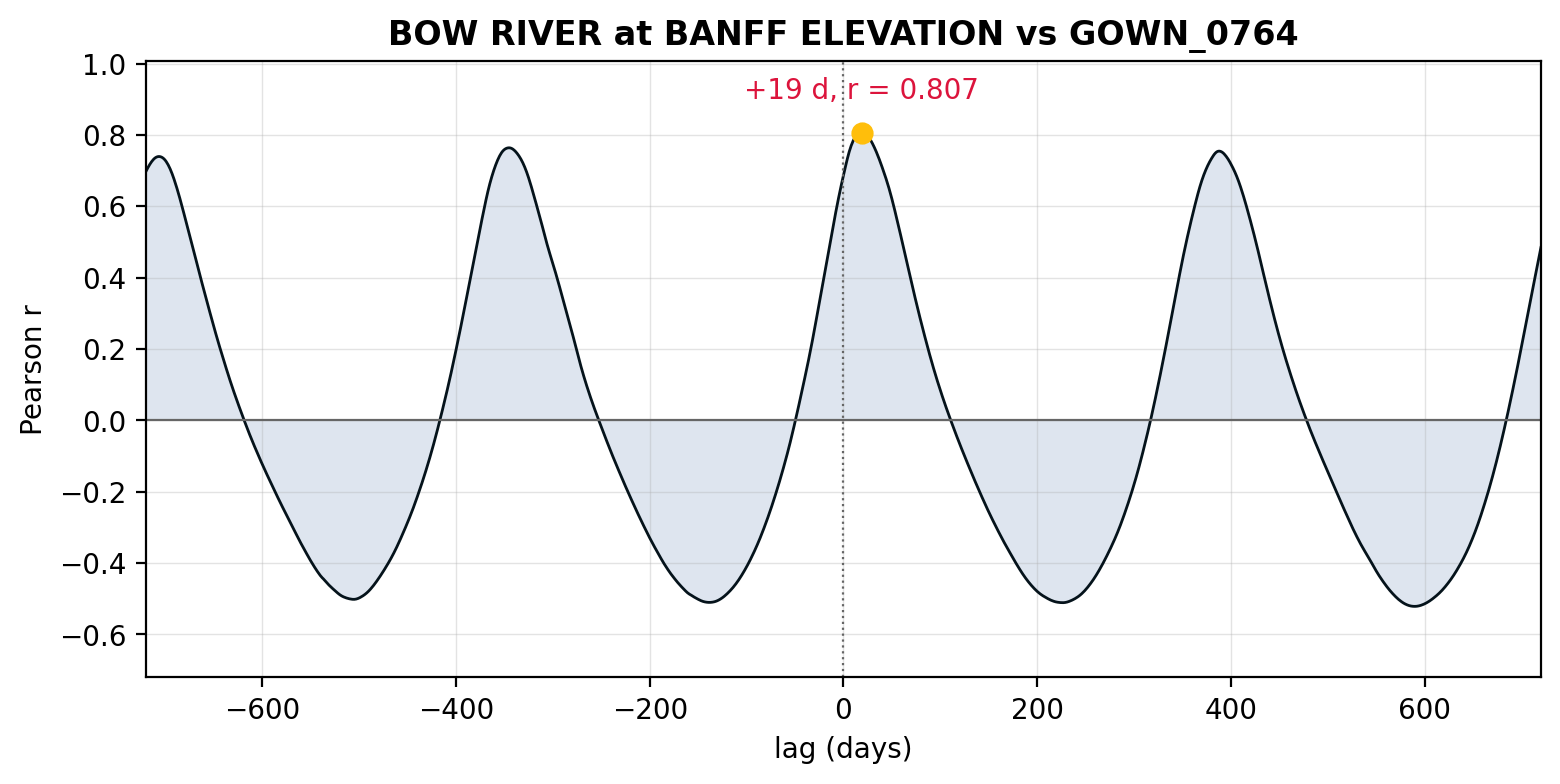

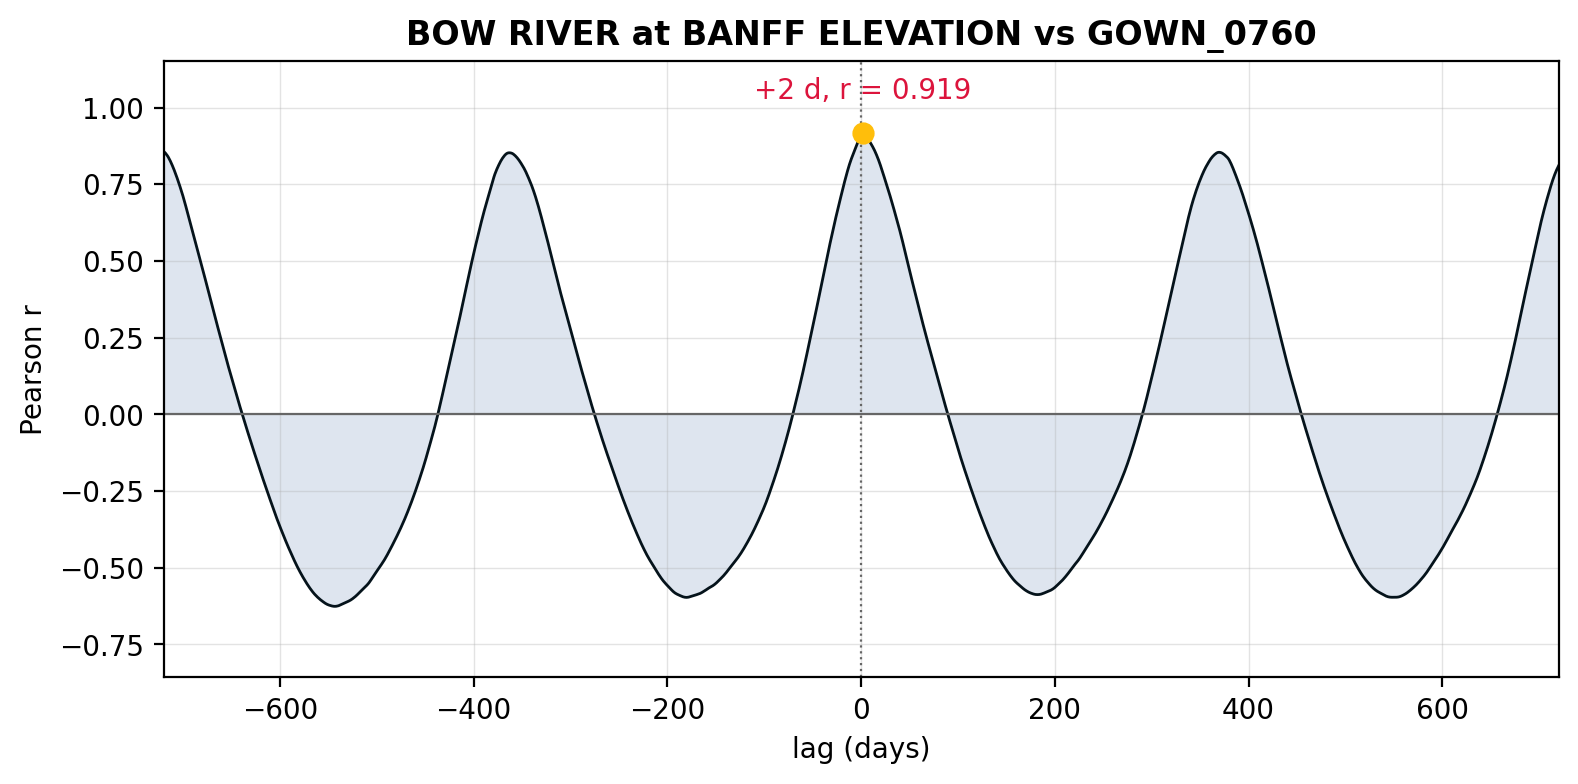

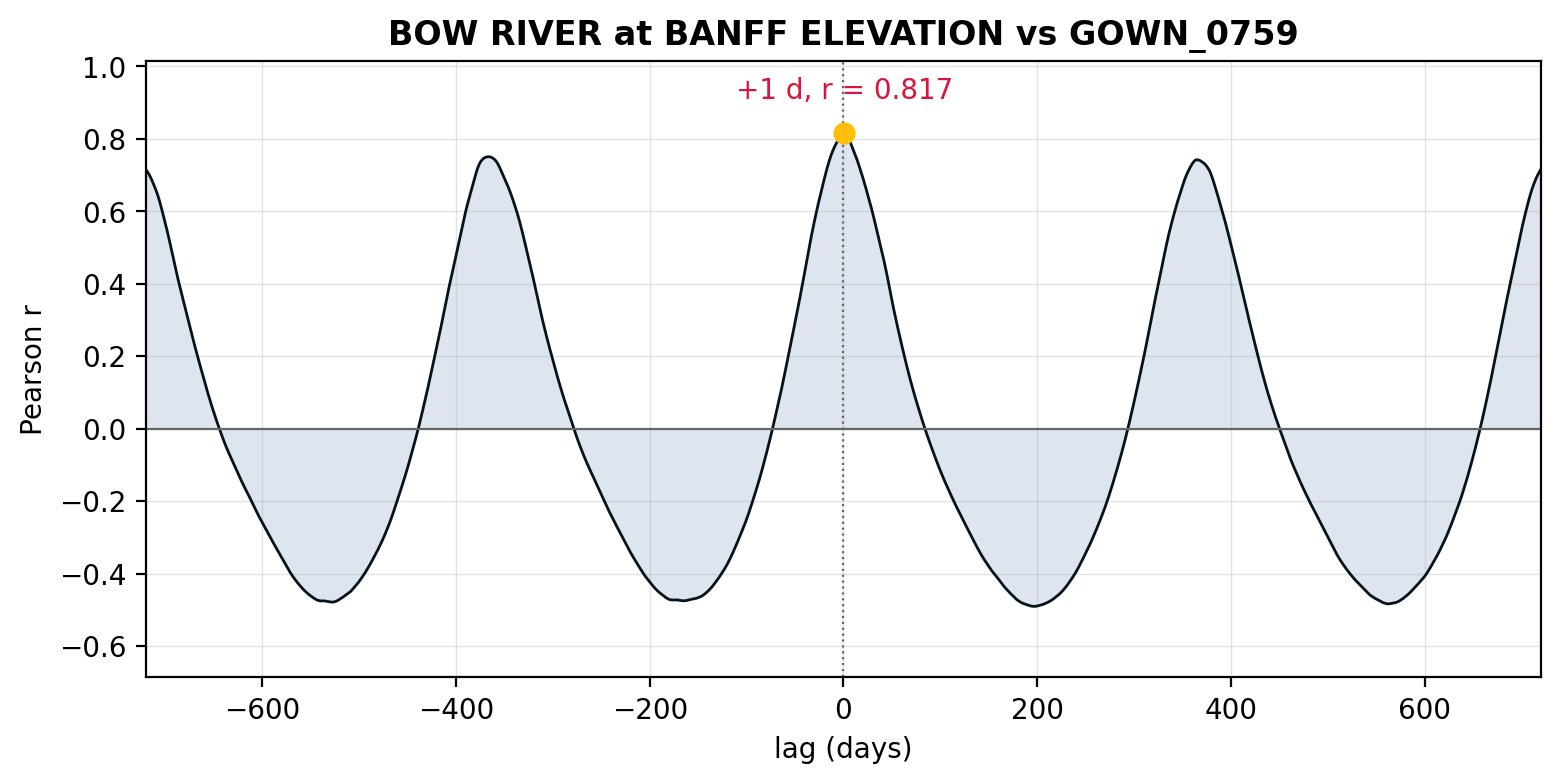

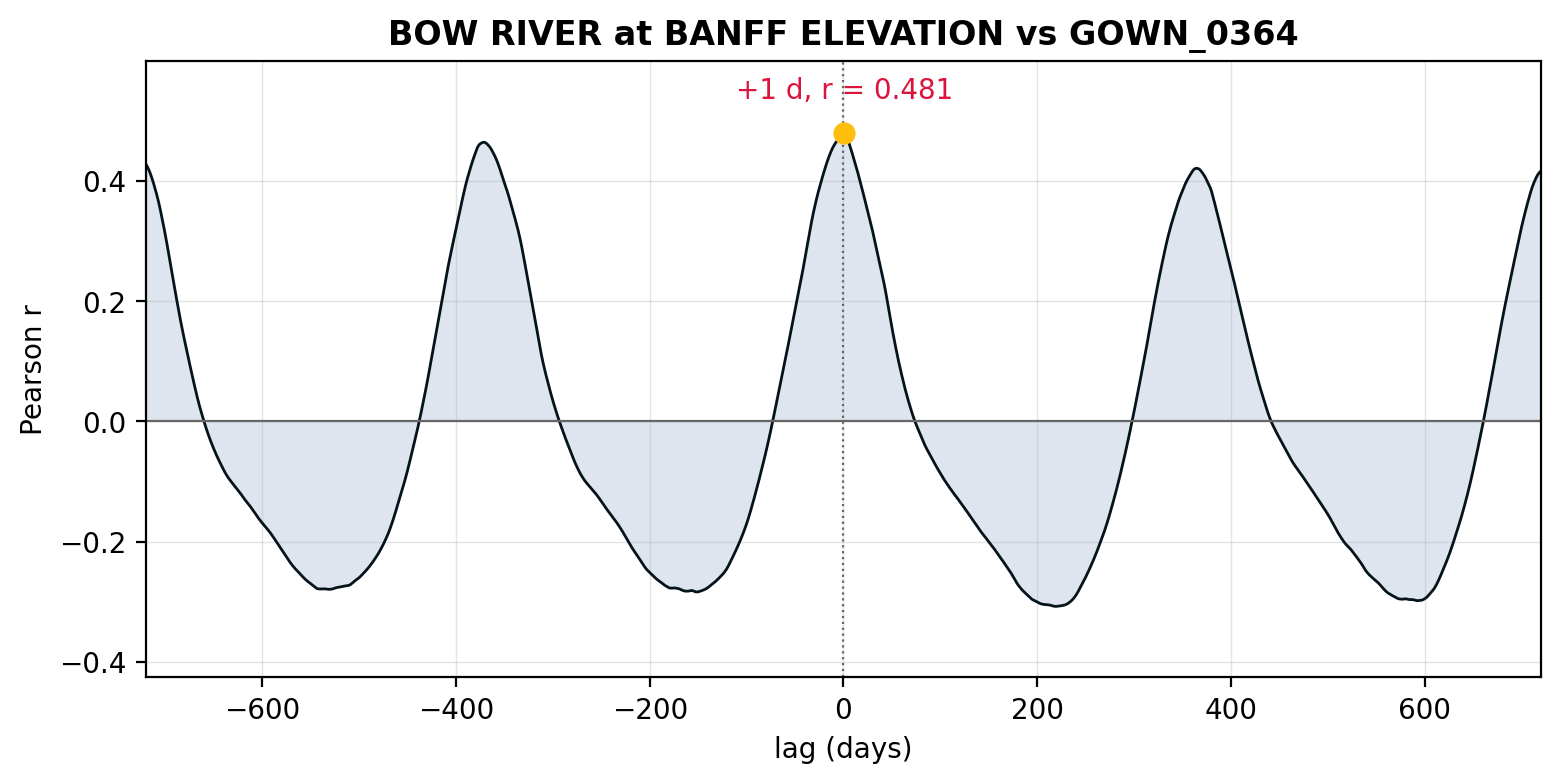

In [21]:
for well in canmore_wells:
    r = xcorr_daily(brab, GOWN[well], max_lag=720)
    plot_xcorr(r, f"BOW RIVER at BANFF ELEVATION vs GOWN_{well}")

# Kananaskis River near Seebe vs MC Wells

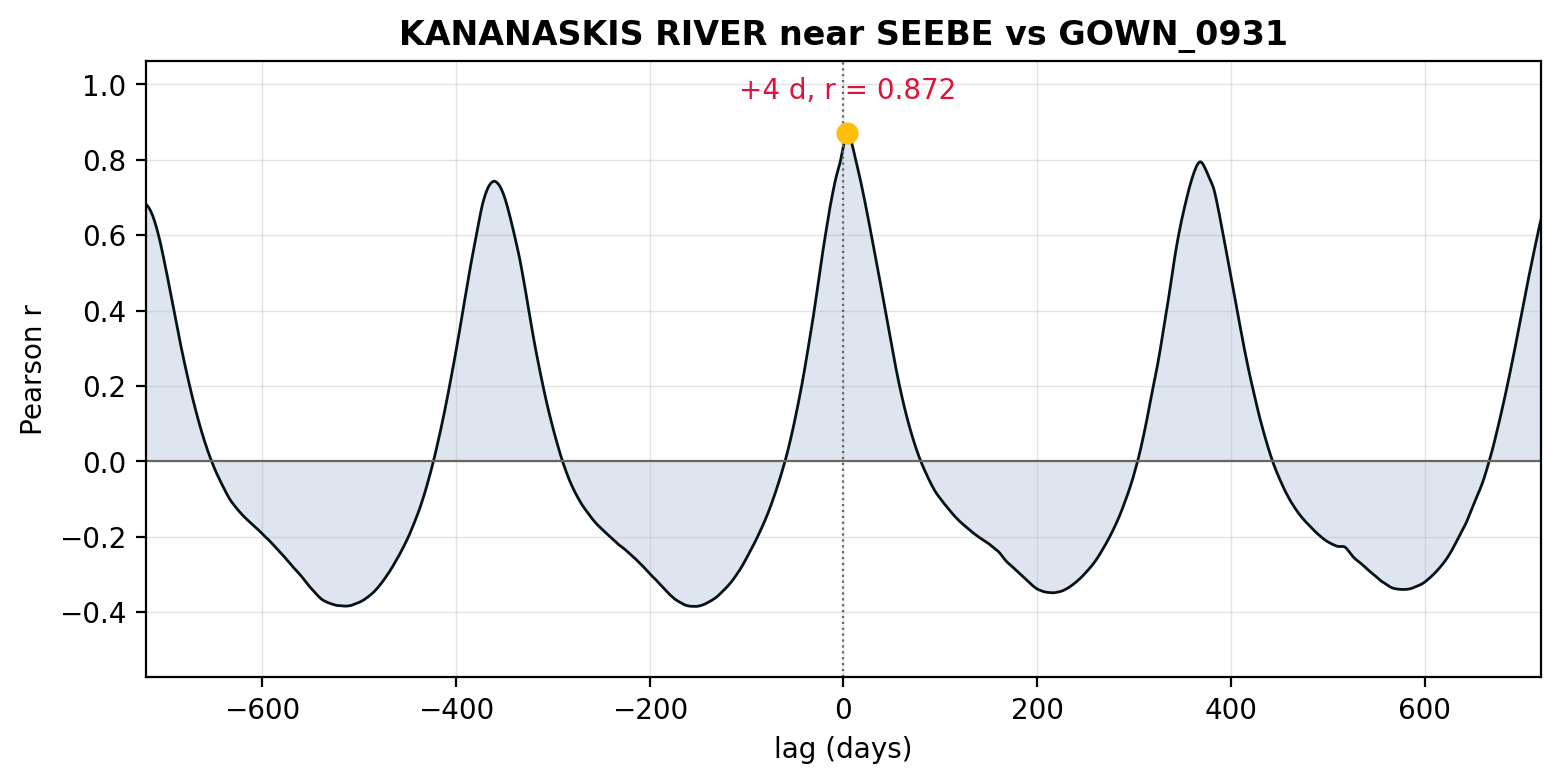

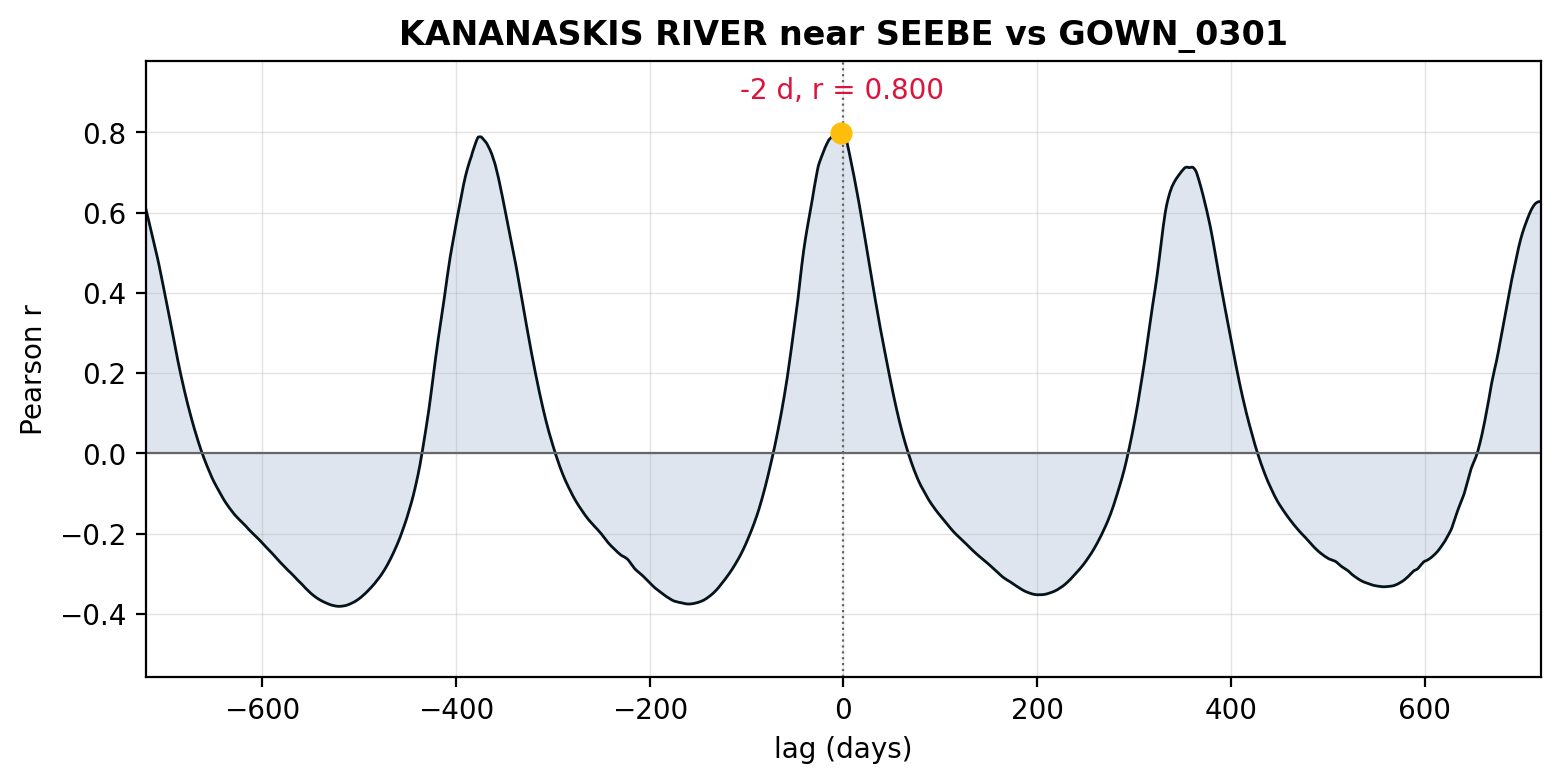

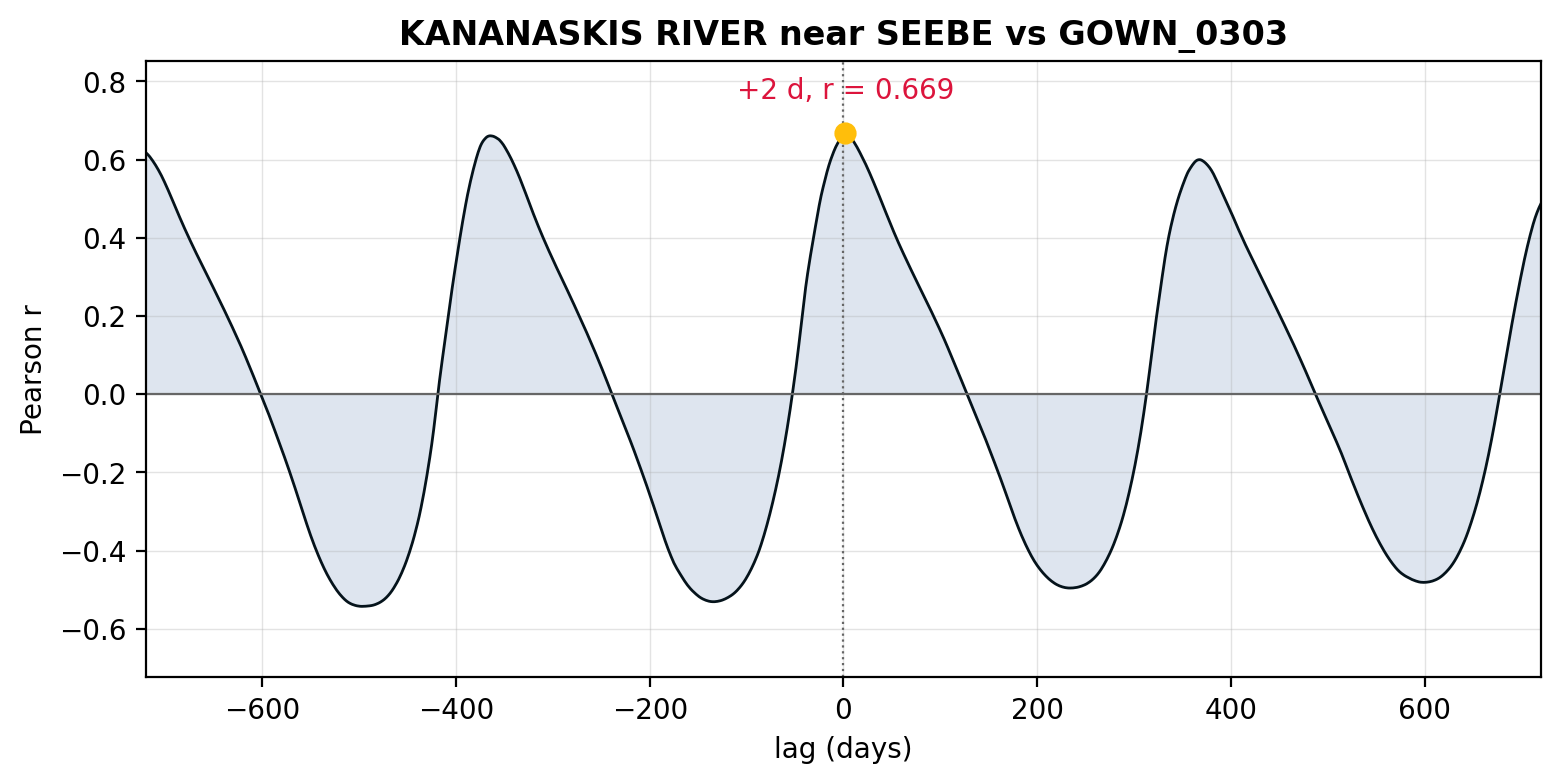

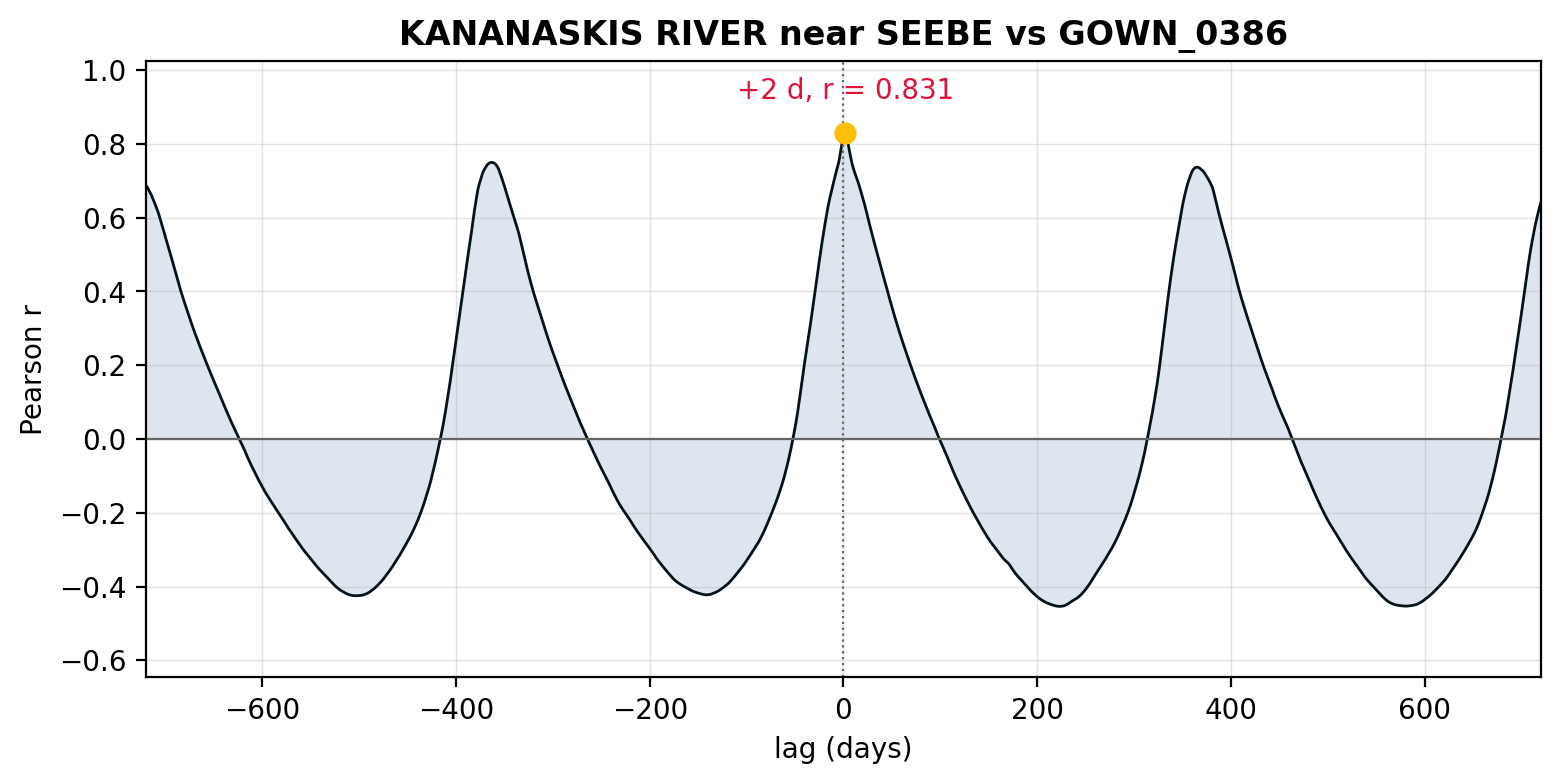

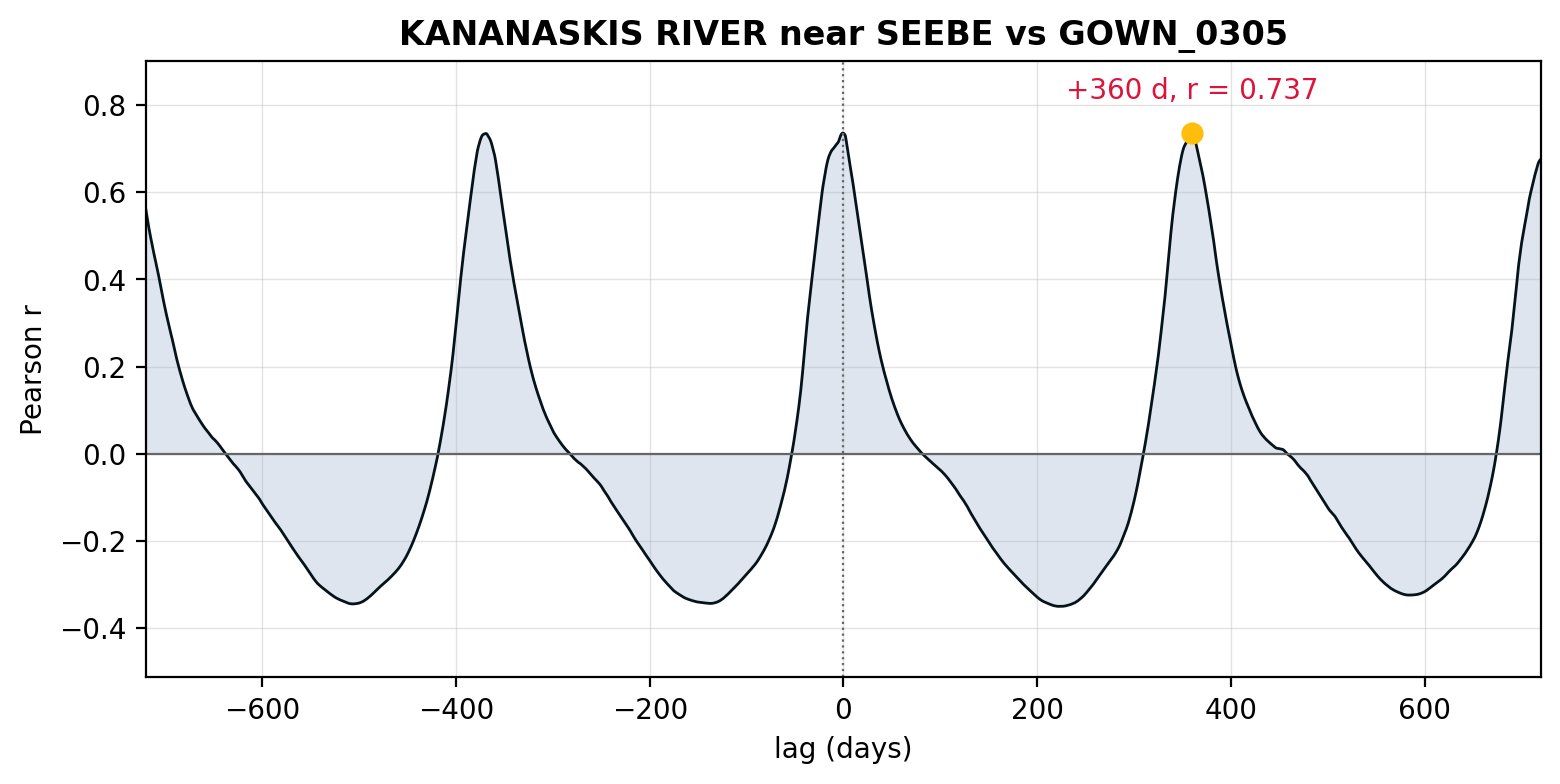

In [20]:
for well in marmot_creek_wells:
    r = xcorr_daily(krns, GOWN[well], max_lag=720)
    plot_xcorr(r, f"KANANASKIS RIVER near SEEBE vs GOWN_{well}")

# Kananaskis River below Barrier Dam vs MC Wells

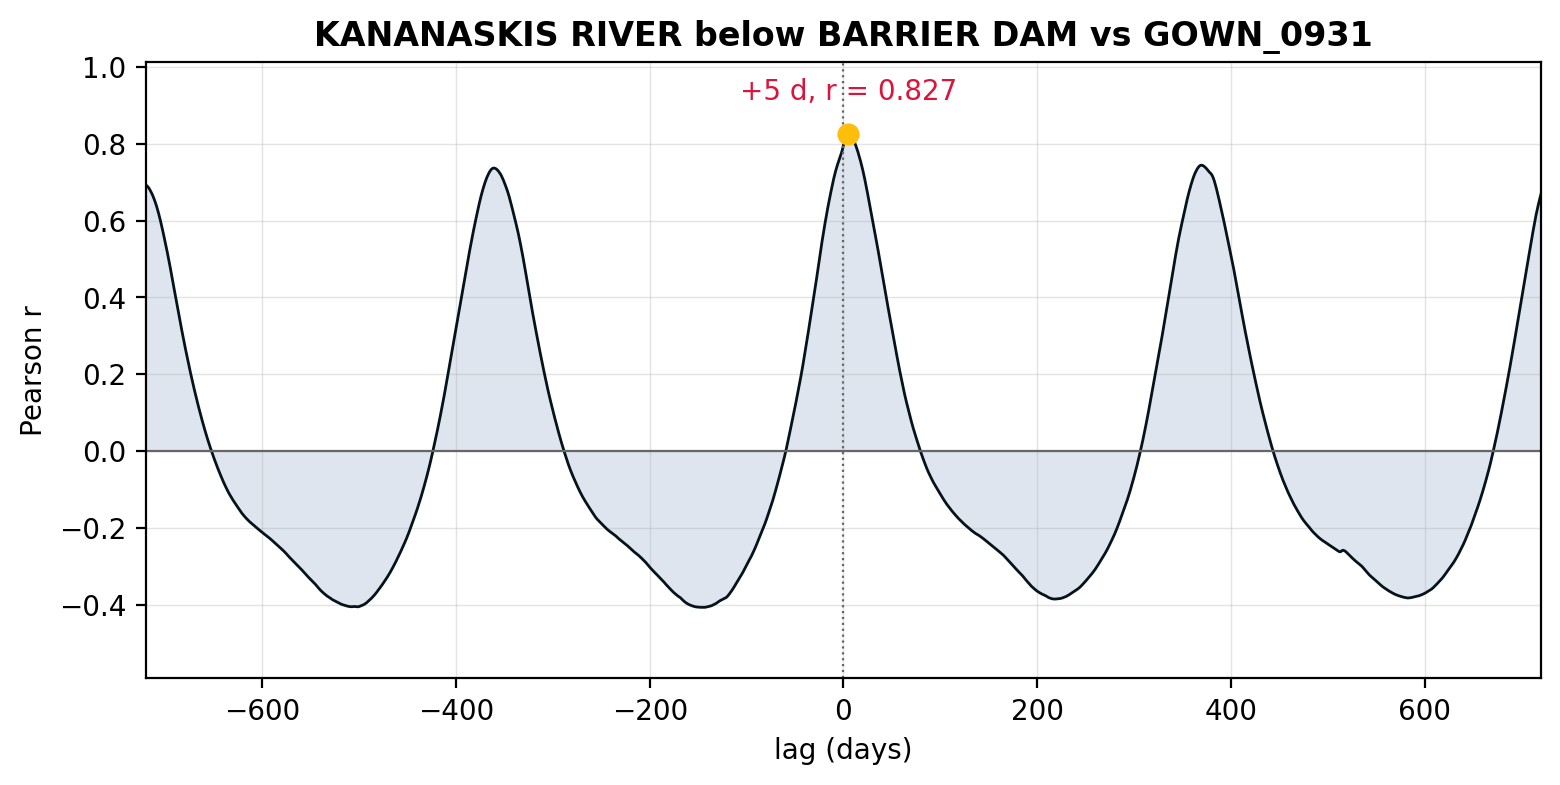

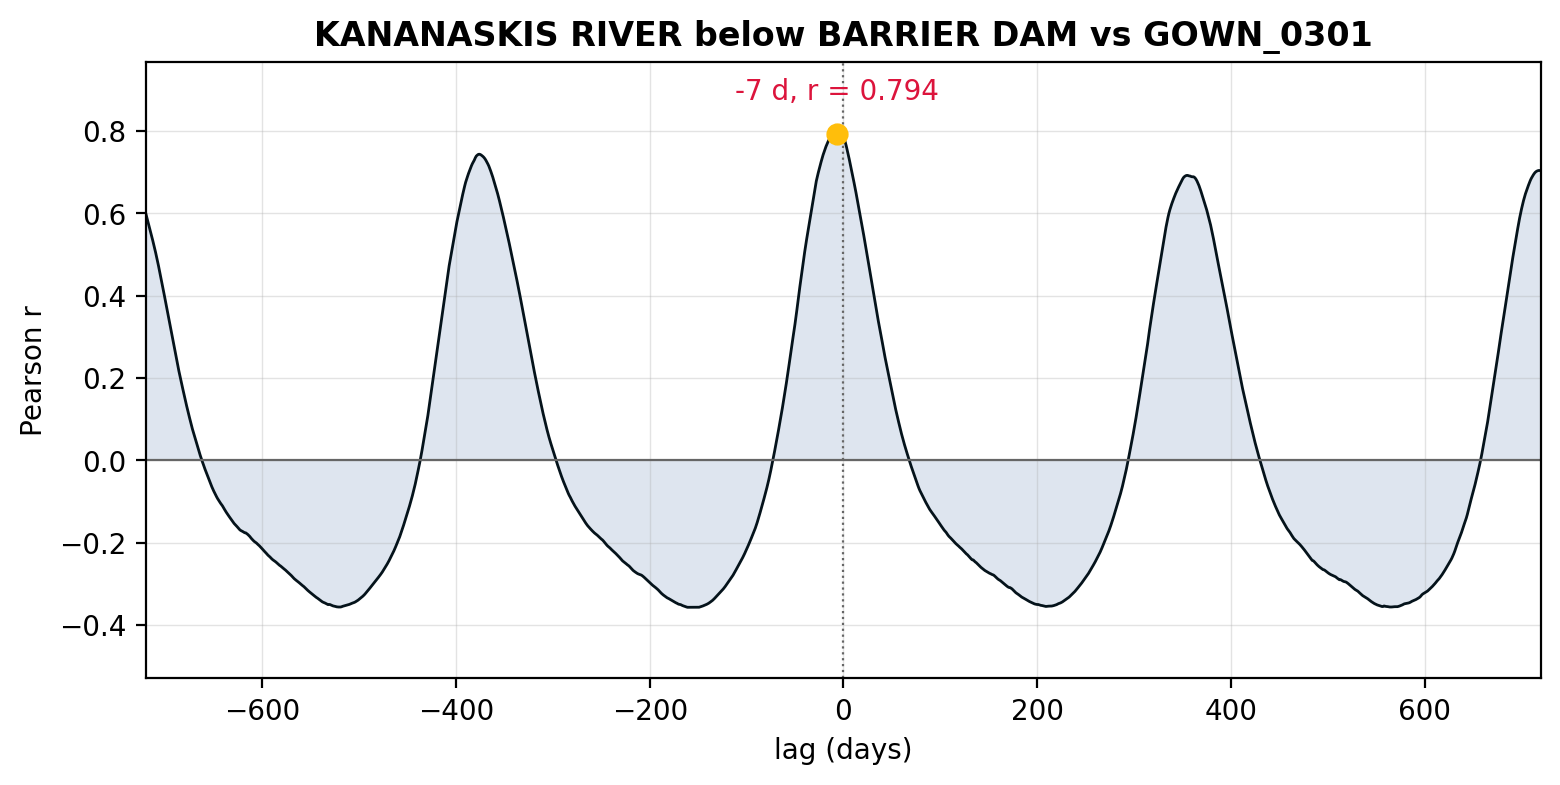

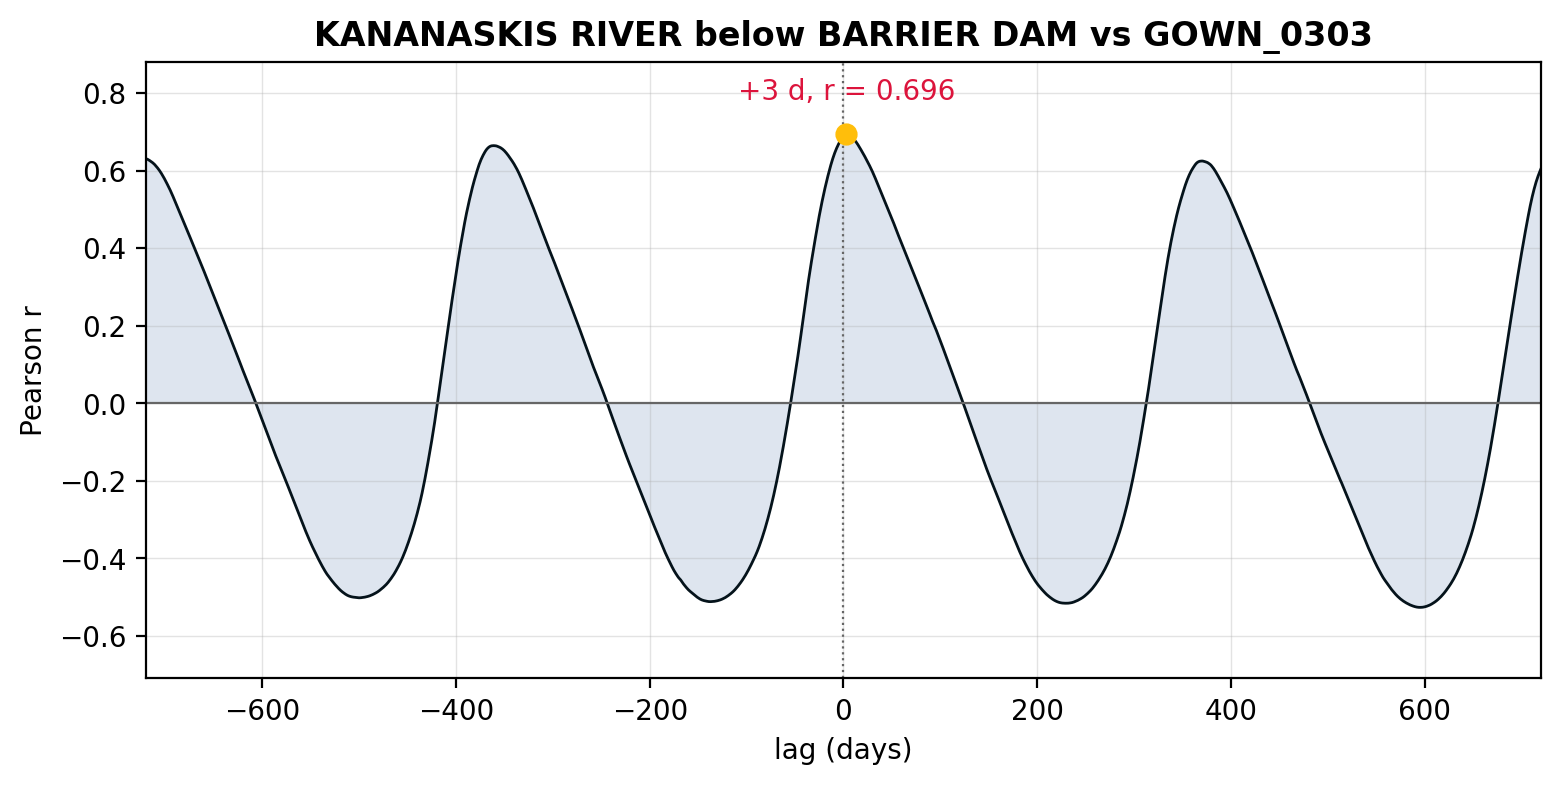

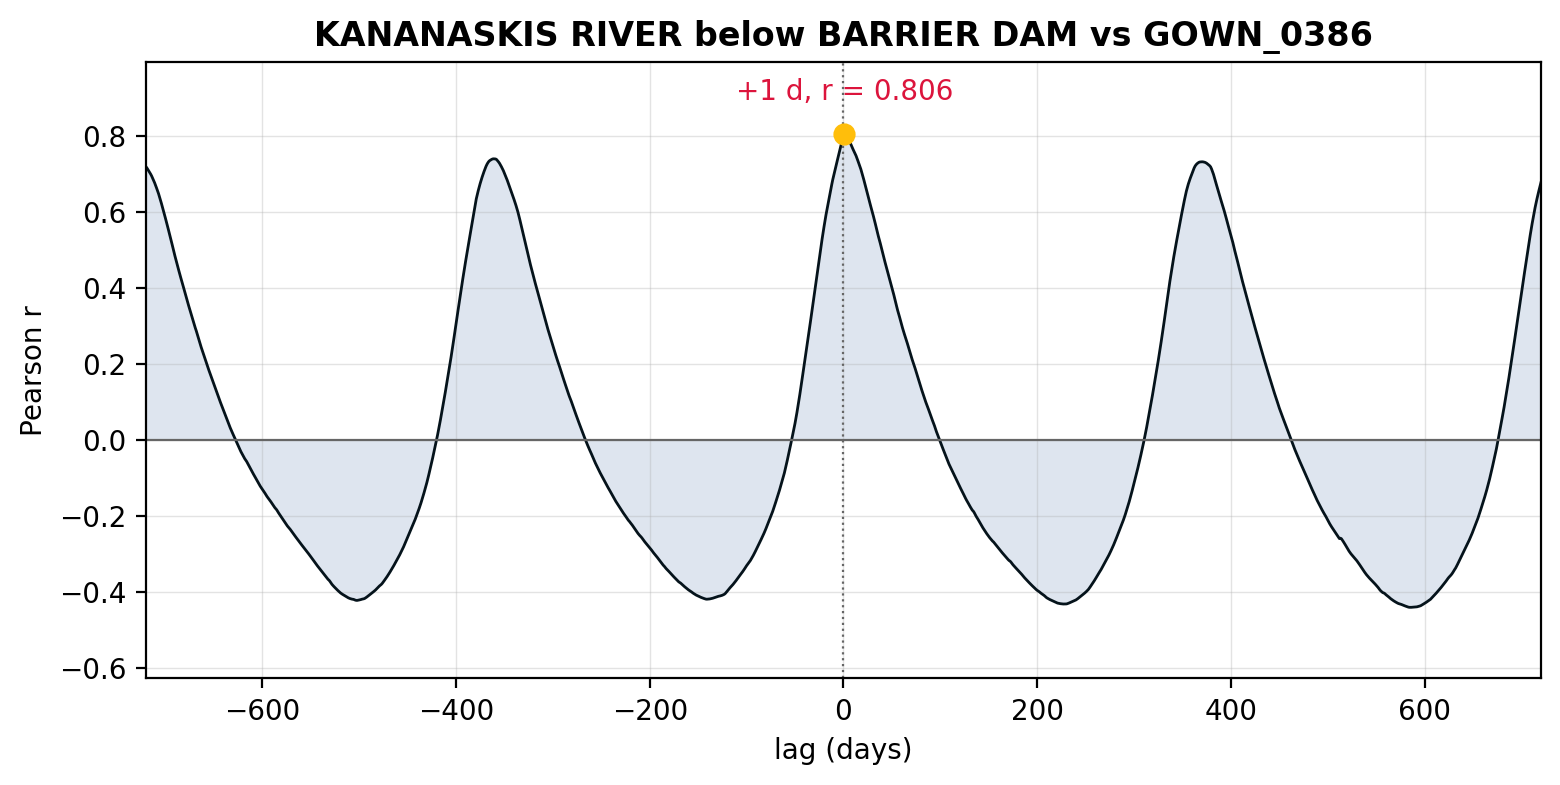

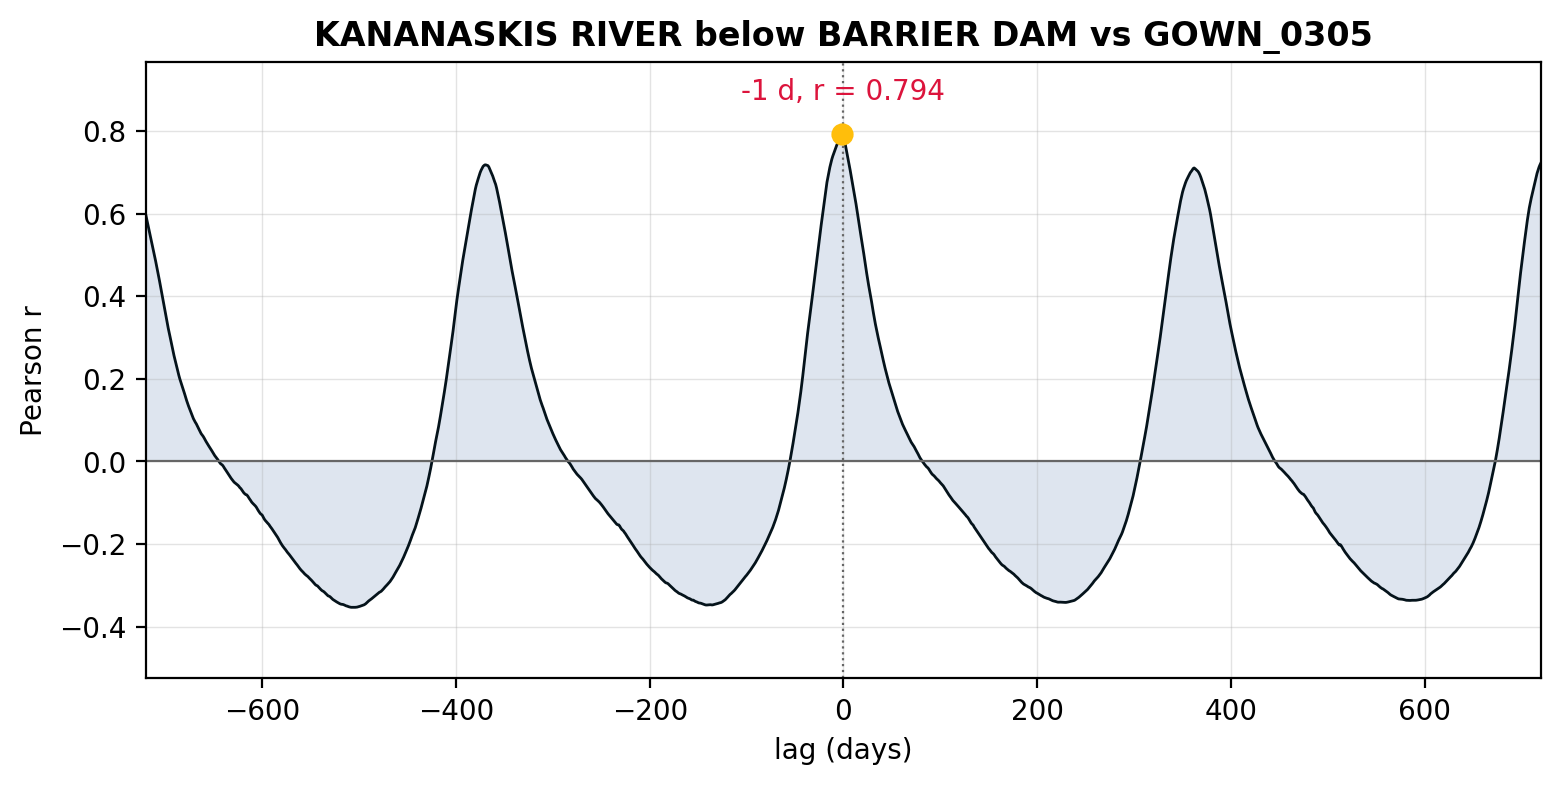

In [22]:
for well in marmot_creek_wells:
    r = xcorr_daily(bl, GOWN[well], max_lag=720)
    plot_xcorr(r, f"KANANASKIS RIVER below BARRIER DAM vs GOWN_{well}")

# Lower Kananaskis Lake vs MC Wells

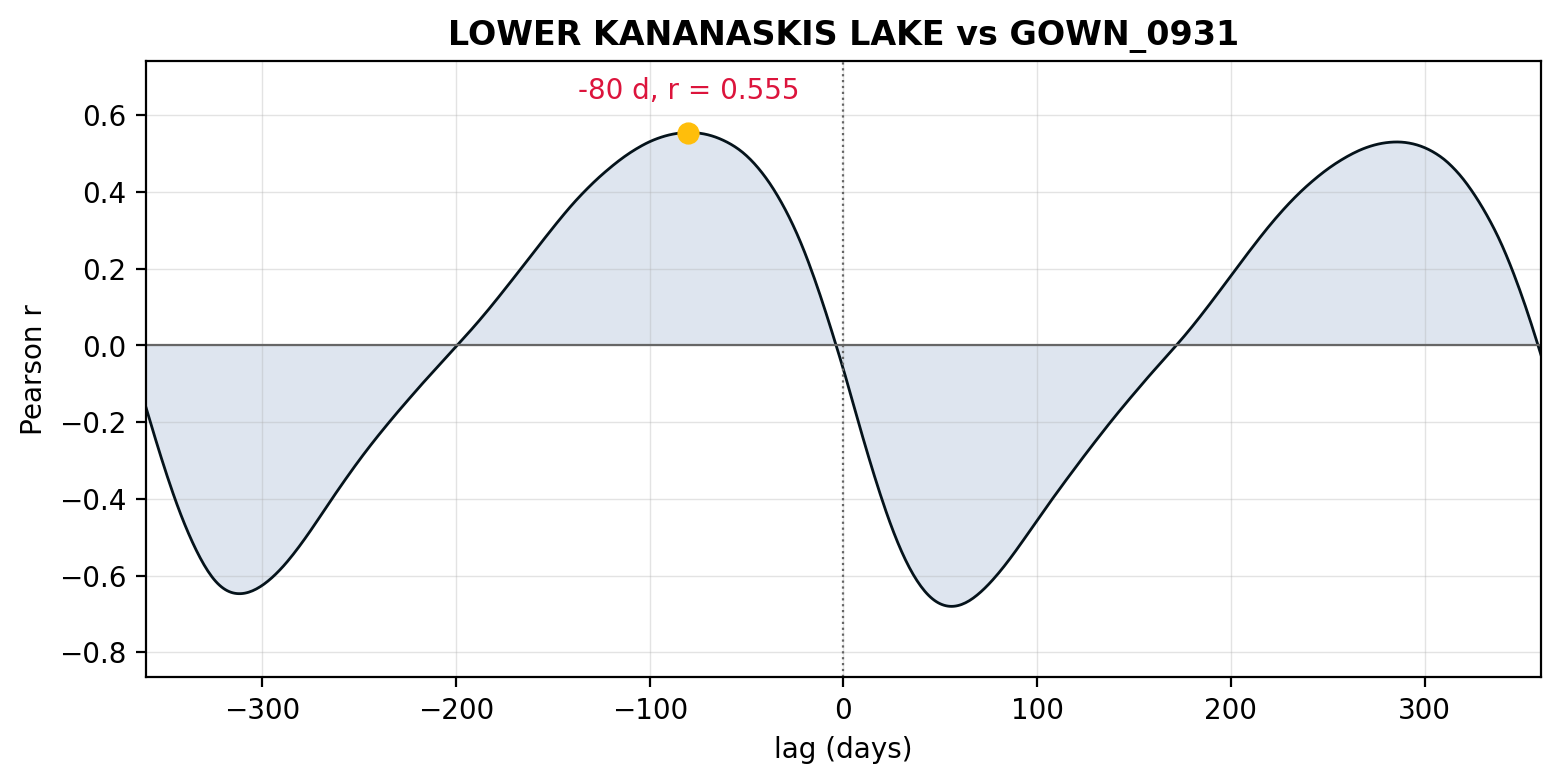

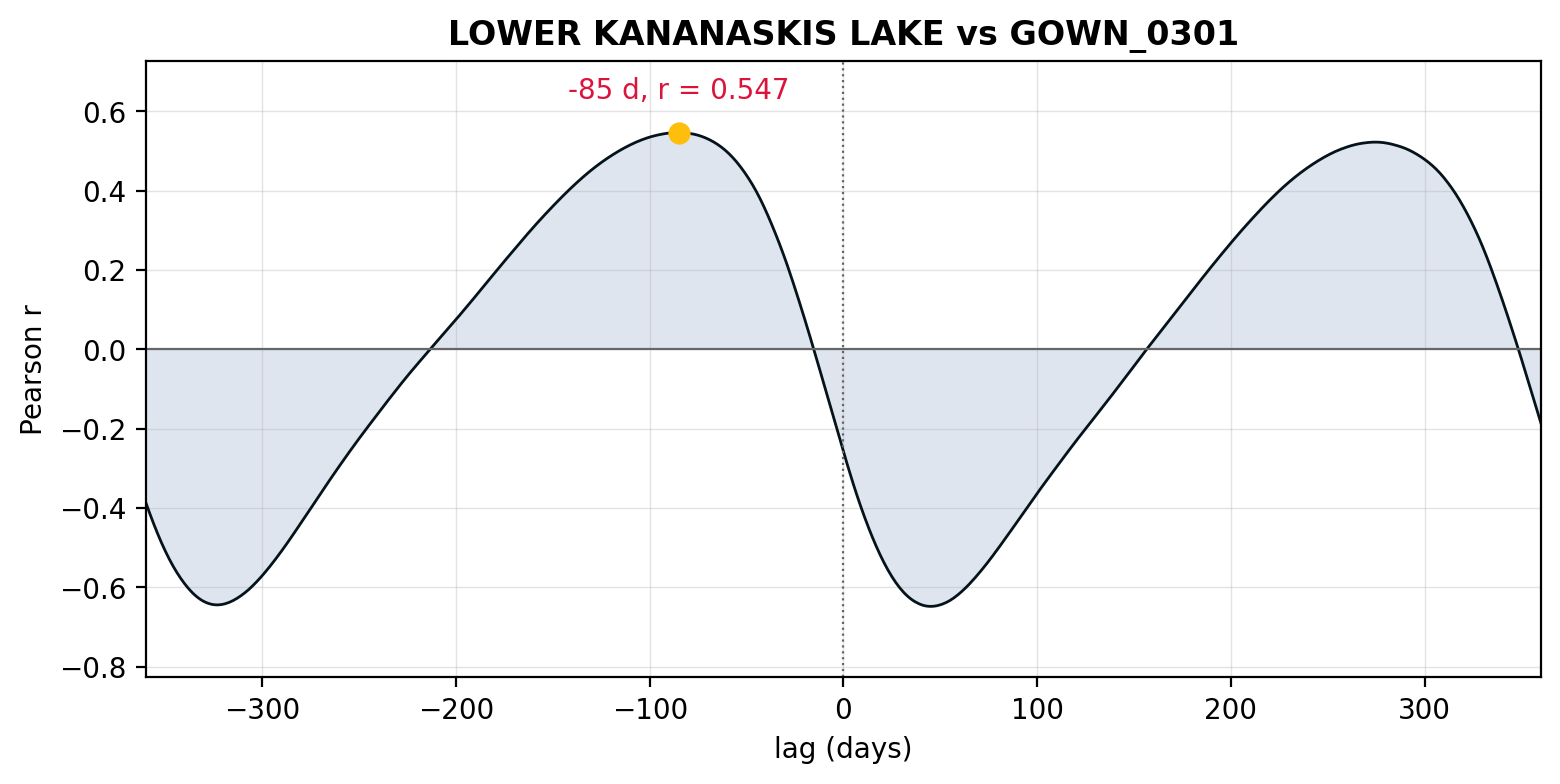

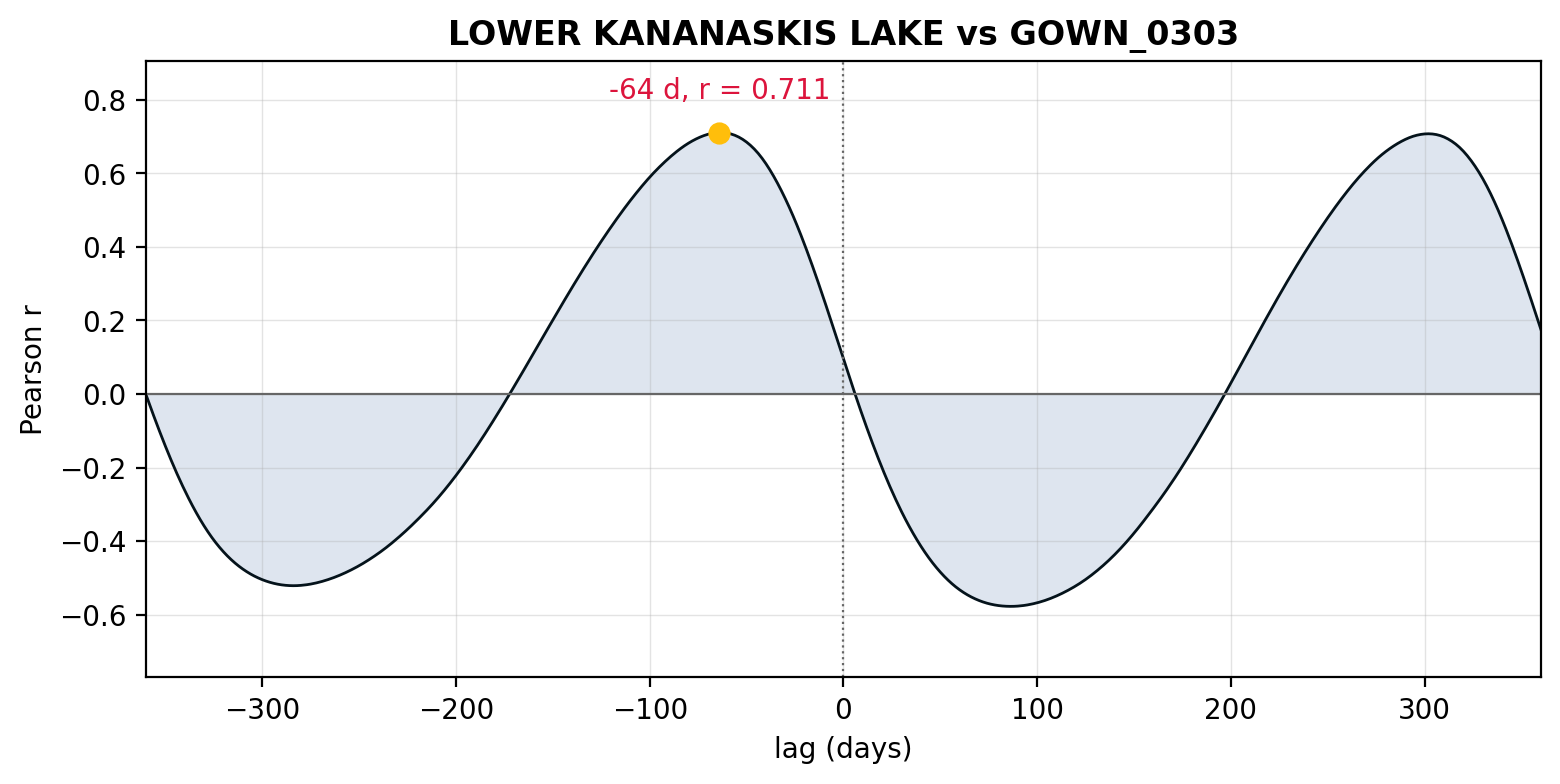

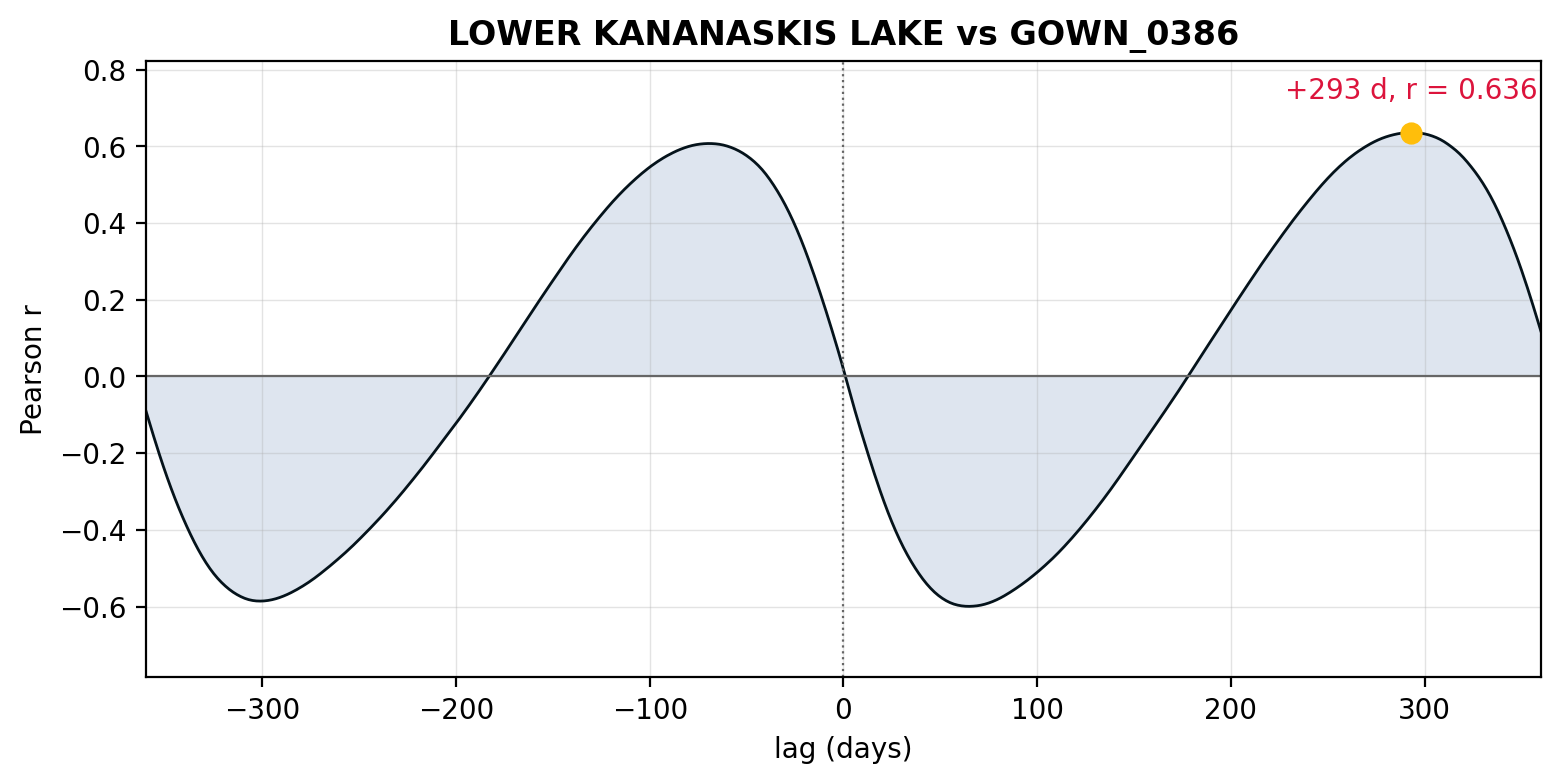

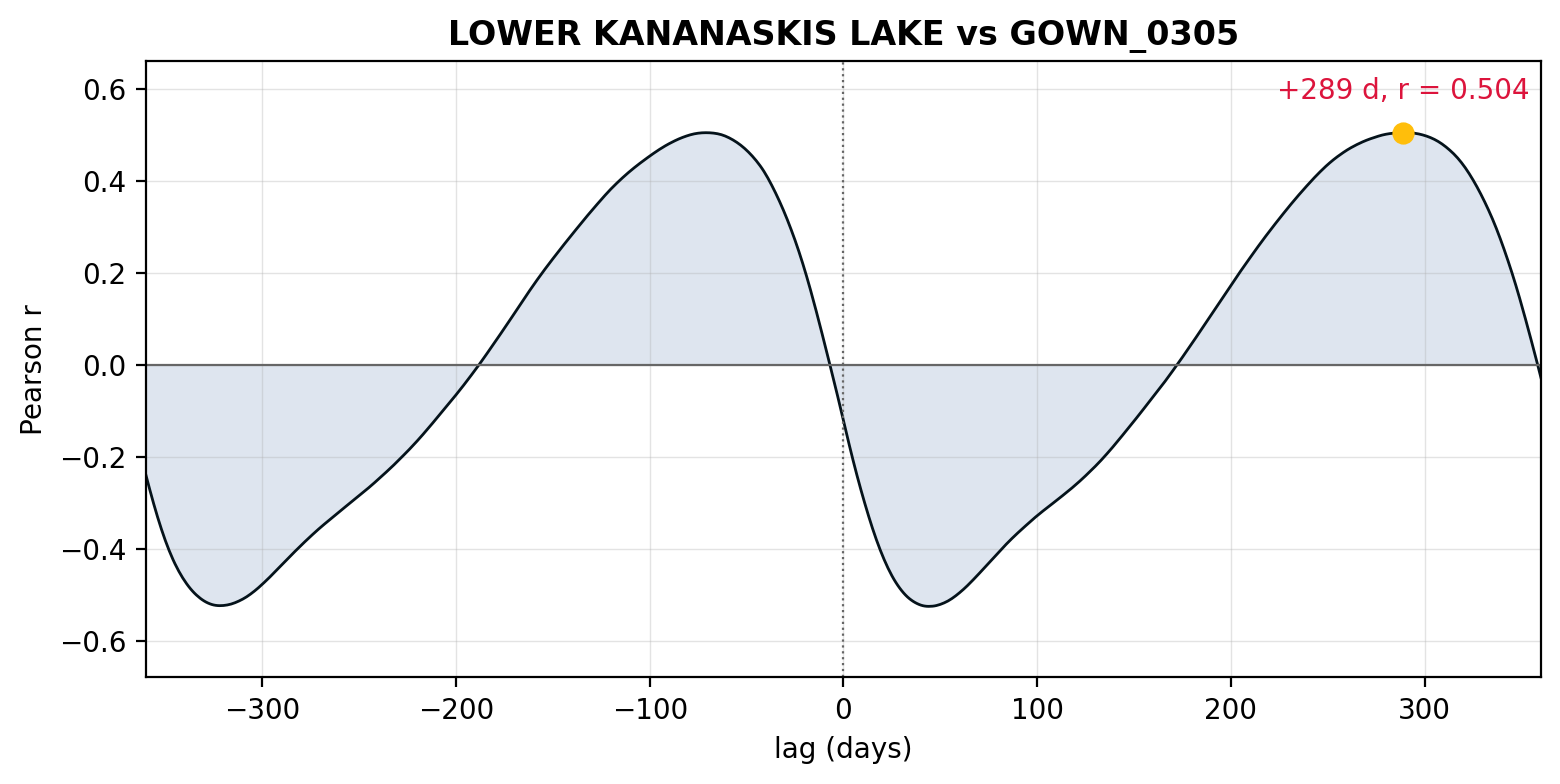

In [24]:
for well in marmot_creek_wells:
    r = xcorr_daily(lkl, GOWN[well], max_lag=360)
    plot_xcorr(r, f"LOWER KANANASKIS LAKE vs GOWN_{well}")

# Jumpingpound Creek vs MC Wells

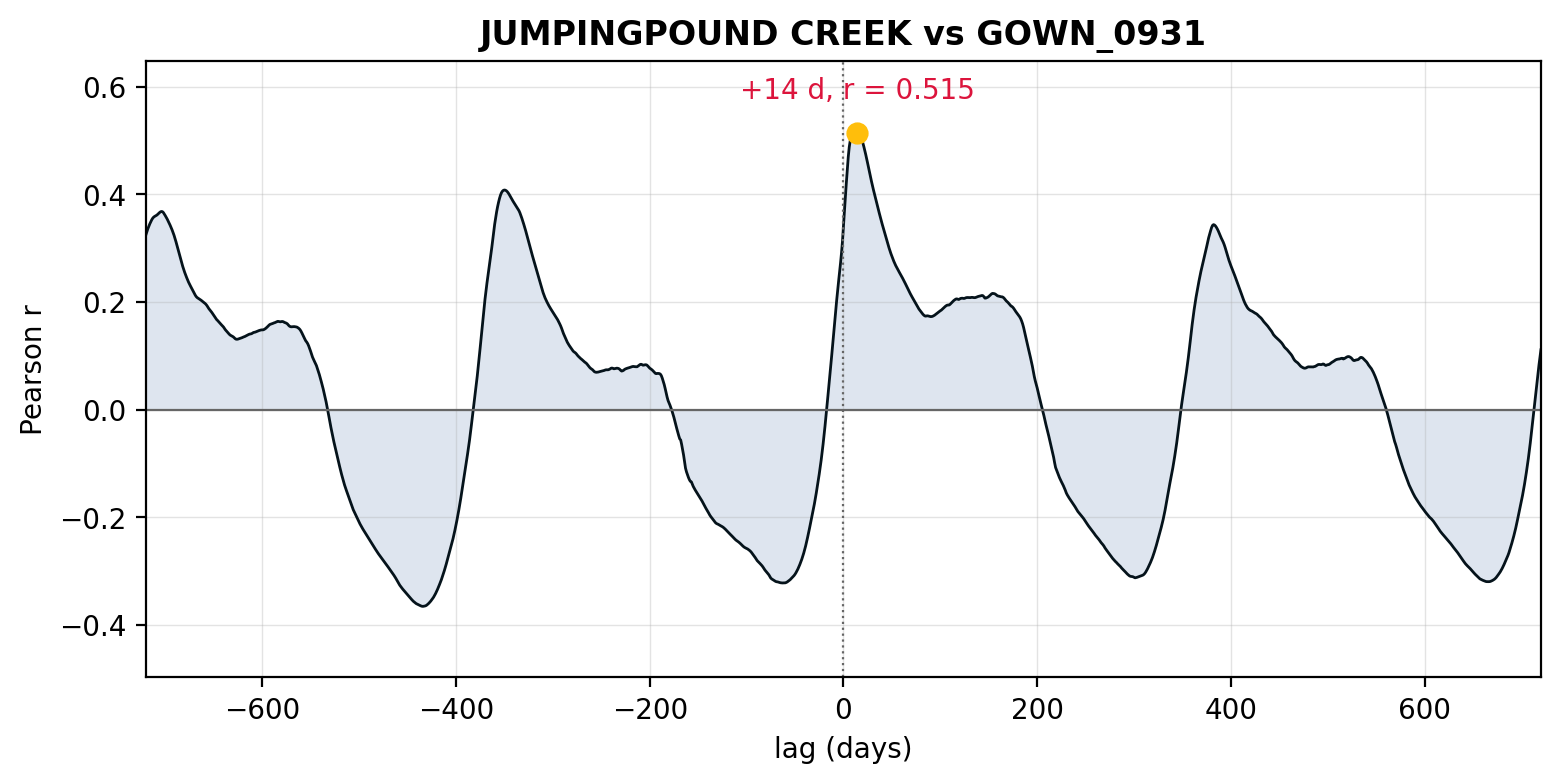

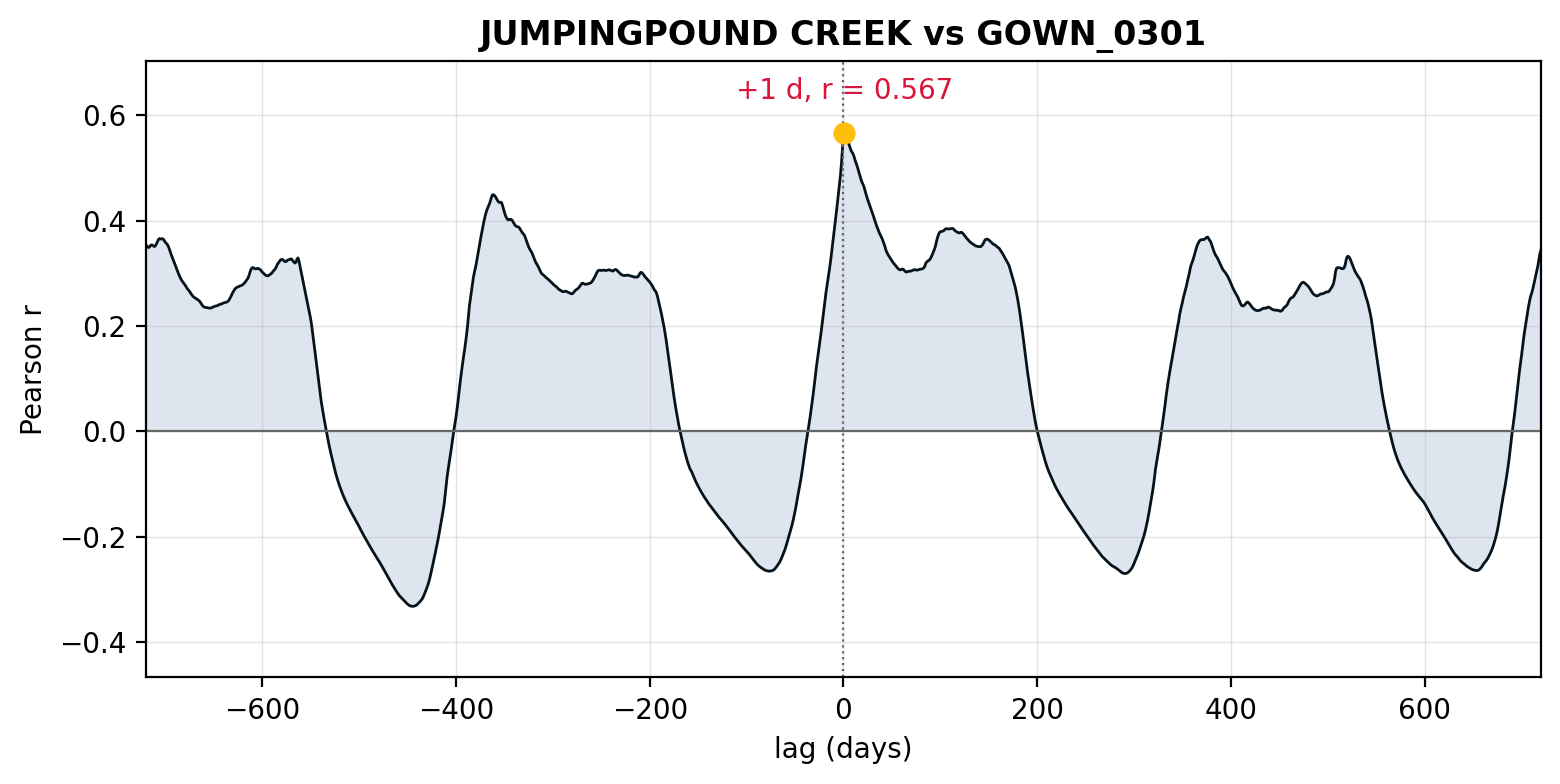

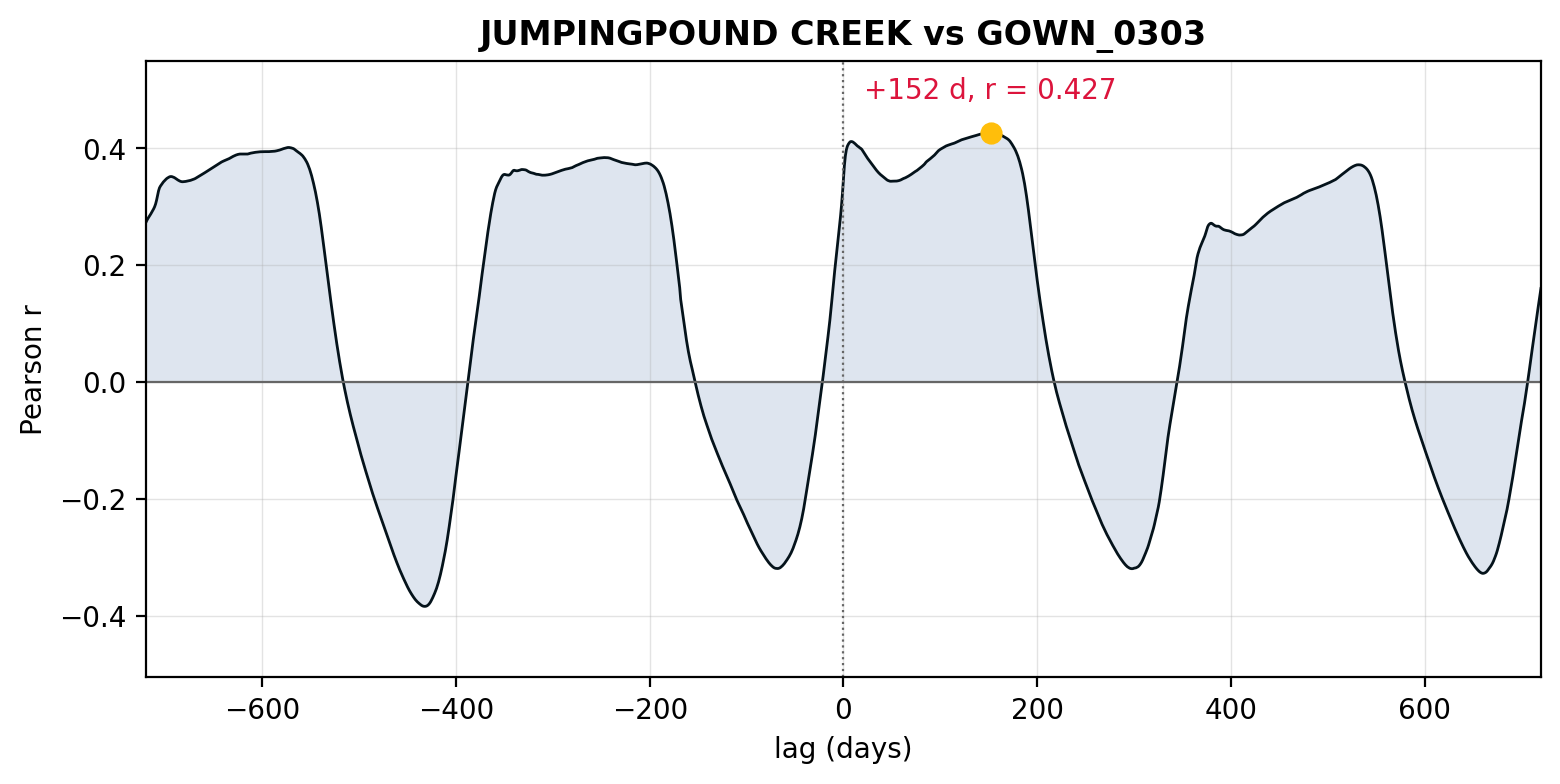

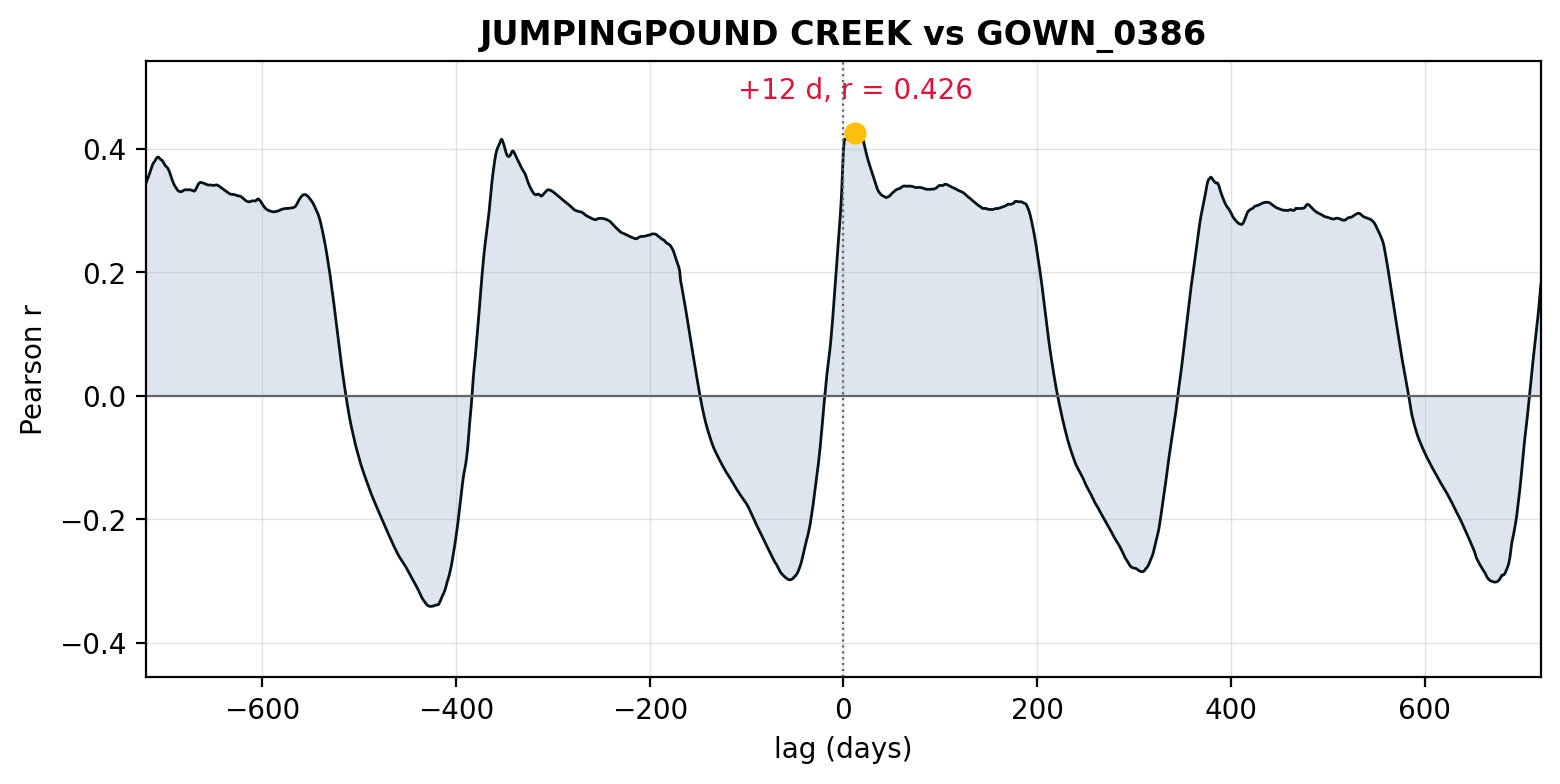

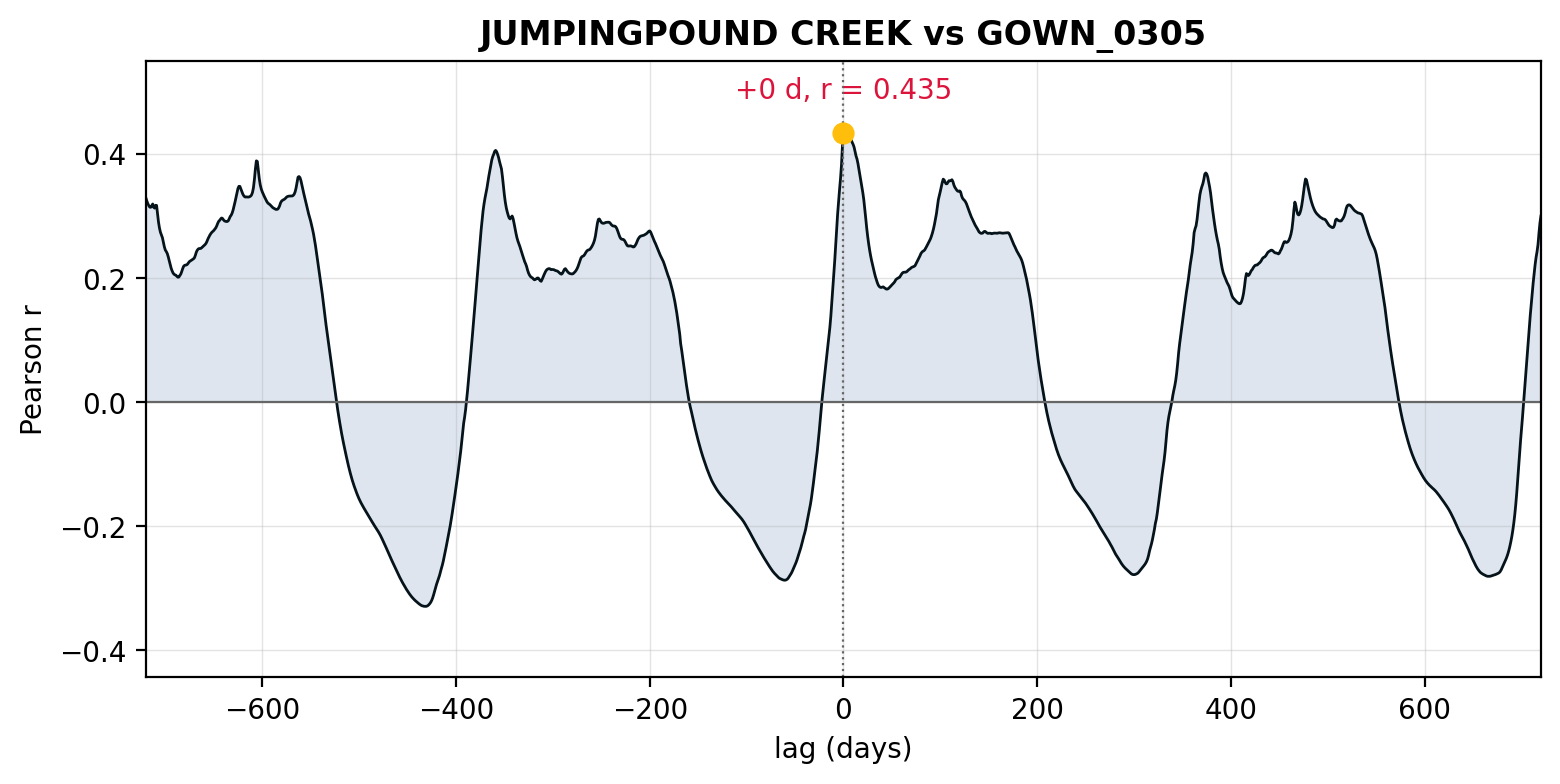

In [28]:
for well in marmot_creek_wells:
    r = xcorr_daily(jcnc, GOWN[well], max_lag=720)
    plot_xcorr(r, f"JUMPINGPOUND CREEK vs GOWN_{well}")